In [1]:
import pandas as pd
import numpy as np

FEATURE_DIR = r"C:\ddata\git program\chf-hrv-risk-prediction\data\processed\features"

ml_dataset = pd.read_csv(
    f"{FEATURE_DIR}\\ml_dataset.csv"
)

print("Shape:", ml_dataset.shape)

print("\nColumns:")
print(ml_dataset.columns.tolist())

print("\nPatients:", ml_dataset["patient_id"].nunique())

print("\nWindows:", len(ml_dataset))

Shape: (11109, 17)

Columns:
['patient_id', 'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'window_id', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend', 'age', 'sex', 'nyha_class', 'risk_label']

Patients: 44

Windows: 11109


In [2]:
ml_dataset = ml_dataset.sort_values(
    ["patient_id", "window_id"]
).reset_index(drop=True)

ordering_check = (
    ml_dataset
    .groupby("patient_id")["window_id"]
    .apply(lambda x: x.is_monotonic_increasing)
)

print(
    "Patients with ordered windows:",
    ordering_check.sum(),
    "/",
    len(ordering_check)
)

print(
    "All patients ordered:",
    ordering_check.all()
)

Patients with ordered windows: 44 / 44
All patients ordered: True


In [3]:
personal_features = [
    "sdnn",
    "rmssd",
    "pnn50",
    "lf_hf"
]

print("Personal baseline features:")
print(personal_features)

print("\nMissing values:")
print(
    ml_dataset[personal_features]
    .isna()
    .sum()
)

Personal baseline features:
['sdnn', 'rmssd', 'pnn50', 'lf_hf']

Missing values:
sdnn     0
rmssd    0
pnn50    0
lf_hf    0
dtype: int64


In [4]:
BASELINE_WINDOW = 32

for feature in personal_features:

    ml_dataset[f"{feature}_baseline_mean"] = (
        ml_dataset
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1).rolling(
                BASELINE_WINDOW,
                min_periods=5
            ).mean()
        )
    )

    ml_dataset[f"{feature}_baseline_std"] = (
        ml_dataset
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1).rolling(
                BASELINE_WINDOW,
                min_periods=5
            ).std()
        )
    )

In [5]:
for feature in personal_features:

    mean_col = f"{feature}_baseline_mean"
    std_col = f"{feature}_baseline_std"

    ml_dataset[f"{feature}_z"] = (
        (
            ml_dataset[feature]
            - ml_dataset[mean_col]
        )
        /
        ml_dataset[std_col].replace(0, np.nan)
    )

In [6]:
z_columns = [
    f"{feature}_z"
    for feature in personal_features
]

ml_dataset["personal_drift_score"] = (
    ml_dataset[z_columns]
    .abs()
    .mean(axis=1)
)

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "personal_drift_score"
        ]
    ].head(20)
)

   patient_id  window_id  personal_drift_score
0       chf01          0                   NaN
1       chf01          1                   NaN
2       chf01          2                   NaN
3       chf01          3                   NaN
4       chf01          4                   NaN
5       chf01          5              1.099020
6       chf01          6              1.036640
7       chf01          7              2.111832
8       chf01          8              0.800840
9       chf01          9              0.825753
10      chf01         10              0.658025
11      chf01         11              0.688162
12      chf01         12              0.522517
13      chf01         13              0.912969
14      chf01         14              0.193154
15      chf01         15              0.729115
16      chf01         16              1.127841
17      chf01         17              1.211748
18      chf01         18              0.607855
19      chf01         19              0.590815


In [7]:
ml_dataset["history_count"] = (
    ml_dataset
    .groupby("patient_id")
    .cumcount()
)

ml_dataset["baseline_confidence"] = np.where(
    ml_dataset["history_count"] >= 5,
    "sufficient",
    "insufficient"
)

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "history_count",
            "baseline_confidence"
        ]
    ].head(15)
)

   patient_id  window_id  history_count baseline_confidence
0       chf01          0              0        insufficient
1       chf01          1              1        insufficient
2       chf01          2              2        insufficient
3       chf01          3              3        insufficient
4       chf01          4              4        insufficient
5       chf01          5              5          sufficient
6       chf01          6              6          sufficient
7       chf01          7              7          sufficient
8       chf01          8              8          sufficient
9       chf01          9              9          sufficient
10      chf01         10             10          sufficient
11      chf01         11             11          sufficient
12      chf01         12             12          sufficient
13      chf01         13             13          sufficient
14      chf01         14             14          sufficient


In [8]:
ml_dataset["drift_flag"] = np.where(
    (
        (ml_dataset["personal_drift_score"] >= 2)
        &
        (ml_dataset["baseline_confidence"] == "sufficient")
    ),
    1,
    0
)

print(
    "Drift flag distribution:"
)

print(
    ml_dataset["drift_flag"].value_counts()
)

print(
    "\nDrift rate:"
)

print(
    ml_dataset["drift_flag"].mean()
)

Drift flag distribution:
drift_flag
0    10546
1      563
Name: count, dtype: int64

Drift rate:
0.05067962912953461


In [9]:
patient_example = (
    ml_dataset[
        ml_dataset["patient_id"] == "chf01"
    ][
        [
            "patient_id",
            "window_id",
            "sdnn",
            "rmssd",
            "pnn50",
            "lf_hf",
            "personal_drift_score",
            "history_count",
            "baseline_confidence",
            "drift_flag"
        ]
    ]
)

print(patient_example.head(40))

   patient_id  window_id       sdnn      rmssd     pnn50     lf_hf  \
0       chf01          0  38.977235  39.595538  1.208459  1.175300   
1       chf01          1  24.194927  12.849903  0.000000  1.163897   
2       chf01          2  40.970951  62.164468  0.986842  0.186097   
3       chf01          3  33.713954  32.012374  6.270627  0.451088   
4       chf01          4  30.488855  25.534032  2.970297  0.780117   
5       chf01          5  24.080741  23.131441  1.337793  1.611112   
6       chf01          6  44.868778  28.242723  3.058104  1.785668   
7       chf01          7  81.308888  23.367511  2.028986  2.175124   
8       chf01          8  19.686808  16.087527  0.531915  1.319495   
9       chf01          9  28.819065  13.676000  0.000000  1.620921   
10      chf01         10  30.037754  16.136173  0.000000  1.533573   
11      chf01         11  21.690820  15.438252  0.314465  1.020018   
12      chf01         12  51.222382  35.747170  0.911854  1.213124   
13      chf01       

In [10]:
patient_drift_summary = (
    ml_dataset
    .groupby("patient_id")
    .agg(
        risk_label=("risk_label", "first"),
        nyha_class=("nyha_class", "first"),
        mean_drift=("personal_drift_score", "mean"),
        max_drift=("personal_drift_score", "max"),
        drift_windows=("drift_flag", "sum"),
        valid_baseline_windows=(
            "baseline_confidence",
            lambda x: (x == "sufficient").sum()
        )
    )
    .reset_index()
)

patient_drift_summary["drift_rate"] = (
    patient_drift_summary["drift_windows"]
    / patient_drift_summary["valid_baseline_windows"]
)

print("Patient-level drift summary:")
print(patient_drift_summary.head())

print("\nMean drift by risk label:")
print(
    patient_drift_summary
    .groupby("risk_label")[
        ["mean_drift", "max_drift", "drift_rate"]
    ]
    .mean()
)

Patient-level drift summary:
  patient_id  risk_label nyha_class  mean_drift  max_drift  drift_windows  \
0      chf01           1     III-IV    0.899233   6.556635             14   
1      chf02           1     III-IV    1.081697   3.345306             24   
2      chf03           1     III-IV    0.806616   3.459658             11   
3      chf04           1     III-IV    0.953556   5.953178             21   
4      chf05           1     III-IV    0.843756   4.499926             12   

   valid_baseline_windows  drift_rate  
0                     235    0.059574  
1                     225    0.106667  
2                     235    0.046809  
3                     235    0.089362  
4                     233    0.051502  

Mean drift by risk label:
            mean_drift  max_drift  drift_rate
risk_label                                   
0             0.900182   5.974412    0.057694
1             0.899050   9.018297    0.049744


In [11]:
print("Drift statistics by NYHA class:")

print(
    patient_drift_summary
    .groupby("nyha_class")[
        [
            "mean_drift",
            "max_drift",
            "drift_rate"
        ]
    ]
    .mean()
)

Drift statistics by NYHA class:
            mean_drift  max_drift  drift_rate
nyha_class                                   
I             0.899664   4.040967    0.054340
II            0.900442   6.941134    0.059372
III           0.870227   6.780217    0.043175
III-IV        0.931716  11.554787    0.057189


In [12]:
print("Window-level drift flag by risk label:")

print(
    pd.crosstab(
        ml_dataset["risk_label"],
        ml_dataset["drift_flag"],
        normalize="index"
    )
)

Window-level drift flag by risk label:
drift_flag         0         1
risk_label                    
0           0.944109  0.055891
1           0.951382  0.048618


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

patient_eval = patient_drift_summary.dropna(
    subset=["mean_drift"]
).copy()

patient_eval["drift_prediction"] = (
    patient_eval["mean_drift"] >= 1.0
).astype(int)

print("Patient-level drift-only evaluation")
print("-----------------------------------")

print(
    "Accuracy:",
    accuracy_score(
        patient_eval["risk_label"],
        patient_eval["drift_prediction"]
    )
)

print(
    "Precision:",
    precision_score(
        patient_eval["risk_label"],
        patient_eval["drift_prediction"],
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        patient_eval["risk_label"],
        patient_eval["drift_prediction"],
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        patient_eval["risk_label"],
        patient_eval["drift_prediction"],
        zero_division=0
    )
)

print(
    "AUROC:",
    roc_auc_score(
        patient_eval["risk_label"],
        patient_eval["mean_drift"]
    )
)

Patient-level drift-only evaluation
-----------------------------------
Accuracy: 0.3181818181818182
Precision: 1.0
Recall: 0.0625
F1: 0.11764705882352941
AUROC: 0.3802083333333333


In [14]:
current_patient_state = (
    ml_dataset
    .sort_values(
        ["patient_id", "window_id"]
    )
    .groupby("patient_id")
    .tail(1)
    [
        [
            "patient_id",
            "window_id",
            "risk_label",
            "nyha_class",
            "personal_drift_score",
            "history_count",
            "baseline_confidence",
            "drift_flag"
        ]
    ]
    .reset_index(drop=True)
)

print("Current patient state:")
print(current_patient_state)

print(
    "\nNumber of patients:",
    len(current_patient_state)
)

Current patient state:
   patient_id  window_id  risk_label nyha_class  personal_drift_score  \
0       chf01        239           1     III-IV              0.425707   
1       chf02        229           1     III-IV              0.617889   
2       chf03        239           1     III-IV              0.892476   
3       chf04        239           1     III-IV              1.181309   
4       chf05        237           1     III-IV              1.300427   
5       chf06        236           1     III-IV              0.377569   
6       chf07        239           1     III-IV              1.358196   
7       chf08        239           1     III-IV              0.524599   
8       chf09        237           1     III-IV              0.942384   
9       chf10        238           1     III-IV              1.147105   
10      chf11        239           1     III-IV              0.640075   
11      chf12        237           1     III-IV              0.255032   
12      chf13        239    

In [15]:
print(
    current_patient_state[
        [
            "personal_drift_score",
            "history_count"
        ]
    ].describe()
)

print("\nCurrent drift flag:")
print(
    current_patient_state["drift_flag"]
    .value_counts()
)

print("\nCurrent drift by risk label:")
print(
    pd.crosstab(
        current_patient_state["risk_label"],
        current_patient_state["drift_flag"],
        normalize="index"
    )
)

       personal_drift_score  history_count
count             44.000000      44.000000
mean               0.995876     251.477273
std                0.598075      22.463913
min                0.108777     195.000000
25%                0.634529     238.750000
50%                0.867835     247.000000
75%                1.219567     272.000000
max                3.287727     287.000000

Current drift flag:
drift_flag
0    42
1     2
Name: count, dtype: int64

Current drift by risk label:
drift_flag       0       1
risk_label                
0           1.0000  0.0000
1           0.9375  0.0625


In [16]:
rf_oof = pd.read_csv(
    "../data/processed/features/patient_rf_oof.csv"
)

print("RF OOF predictions:")
print(rf_oof.head())

print("\nShape:", rf_oof.shape)

RF OOF predictions:
  patient_id  risk_label  rf_probability  rf_prediction
0      chf01           1        0.973139              1
1      chf02           1        0.958493              1
2      chf03           1        0.708278              1
3      chf04           1        0.385208              0
4      chf05           1        0.719146              1

Shape: (44, 4)


In [17]:
patient_personalized = (
    current_patient_state[
        [
            "patient_id",
            "risk_label",
            "personal_drift_score",
            "history_count",
            "baseline_confidence",
            "drift_flag"
        ]
    ]
    .merge(
        rf_oof[
            [
                "patient_id",
                "rf_probability"
            ]
        ],
        on="patient_id",
        how="inner"
    )
)

print("Personalized patient dataset:")
print(patient_personalized.head())

print("\nShape:", patient_personalized.shape)
print("\nColumns:")
print(patient_personalized.columns.tolist())

Personalized patient dataset:
  patient_id  risk_label  personal_drift_score  history_count  \
0      chf01           1              0.425707            239   
1      chf02           1              0.617889            229   
2      chf03           1              0.892476            239   
3      chf04           1              1.181309            239   
4      chf05           1              1.300427            237   

  baseline_confidence  drift_flag  rf_probability  
0          sufficient           0        0.973139  
1          sufficient           0        0.958493  
2          sufficient           0        0.708278  
3          sufficient           0        0.385208  
4          sufficient           0        0.719146  

Shape: (44, 7)

Columns:
['patient_id', 'risk_label', 'personal_drift_score', 'history_count', 'baseline_confidence', 'drift_flag', 'rf_probability']


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Baseline RF probability:")
print(
    patient_personalized[
        ["patient_id", "risk_label", "rf_probability"]
    ].head()
)

print("\nPersonal drift:")
print(
    patient_personalized[
        ["patient_id", "personal_drift_score", "drift_flag"]
    ].head()
)

Baseline RF probability:
  patient_id  risk_label  rf_probability
0      chf01           1        0.973139
1      chf02           1        0.958493
2      chf03           1        0.708278
3      chf04           1        0.385208
4      chf05           1        0.719146

Personal drift:
  patient_id  personal_drift_score  drift_flag
0      chf01              0.425707           0
1      chf02              0.617889           0
2      chf03              0.892476           0
3      chf04              1.181309           0
4      chf05              1.300427           0


In [19]:
print("\nCorrelation with risk label:")

print(
    patient_personalized[
        [
            "risk_label",
            "rf_probability",
            "personal_drift_score",
            "drift_flag"
        ]
    ].corr(numeric_only=True)["risk_label"]
)


Correlation with risk label:
risk_label              1.000000
rf_probability          0.146343
personal_drift_score    0.083094
drift_flag              0.133631
Name: risk_label, dtype: float64


In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

personalized_df = patient_personalized.copy()

personalized_df["baseline_confidence_binary"] = (
    personalized_df["baseline_confidence"] == "sufficient"
).astype(int)

print(personalized_df[
    [
        "patient_id",
        "risk_label",
        "rf_probability",
        "personal_drift_score",
        "drift_flag",
        "history_count",
        "baseline_confidence_binary"
    ]
].head())

print("\nShape:", personalized_df.shape)

  patient_id  risk_label  rf_probability  personal_drift_score  drift_flag  \
0      chf01           1        0.973139              0.425707           0   
1      chf02           1        0.958493              0.617889           0   
2      chf03           1        0.708278              0.892476           0   
3      chf04           1        0.385208              1.181309           0   
4      chf05           1        0.719146              1.300427           0   

   history_count  baseline_confidence_binary  
0            239                           1  
1            229                           1  
2            239                           1  
3            239                           1  
4            237                           1  

Shape: (44, 8)


In [21]:
y = personalized_df["risk_label"].values
rf_prob = personalized_df["rf_probability"].values

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_results = []

for fold, (_, val_idx) in enumerate(
    skf.split(personalized_df, y), 1
):

    y_val = y[val_idx]
    prob_val = rf_prob[val_idx]
    pred_val = (prob_val >= 0.5).astype(int)

    rf_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val, pred_val),
        "precision": precision_score(
            y_val, pred_val, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred_val, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred_val, zero_division=0
        ),
        "auroc": roc_auc_score(
            y_val, prob_val
        )
    })

rf_results_df = pd.DataFrame(rf_results)

print("RF Probability Baseline")
print("-----------------------")
print(rf_results_df)

print("\nMean:")
print(
    rf_results_df
    .drop(columns="fold")
    .mean()
)

print("\nStd:")
print(
    rf_results_df
    .drop(columns="fold")
    .std()
)

RF Probability Baseline
-----------------------
   fold  accuracy  precision    recall        f1     auroc
0     1  0.777778   0.777778  1.000000  0.875000  0.642857
1     2  0.666667   0.833333  0.714286  0.769231  0.571429
2     3  0.555556   0.666667  0.666667  0.666667  0.555556
3     4  0.888889   0.857143  1.000000  0.923077  0.722222
4     5  0.625000   0.714286  0.833333  0.769231  0.333333

Mean:
accuracy     0.702778
precision    0.769841
recall       0.842857
f1           0.800641
auroc        0.565079
dtype: float64

Std:
accuracy     0.131615
precision    0.079761
recall       0.155766
f1           0.100551
auroc        0.145414
dtype: float64


In [22]:
personal_features = [
    "rf_probability",
    "personal_drift_score",
    "drift_flag",
    "history_count",
    "baseline_confidence_binary"
]

X_personal = personalized_df[personal_features].values

print("Personalized feature matrix shape:")
print(X_personal.shape)

print("\nFeatures:")
print(personal_features)

Personalized feature matrix shape:
(44, 5)

Features:
['rf_probability', 'personal_drift_score', 'drift_flag', 'history_count', 'baseline_confidence_binary']


In [23]:
personal_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_personal, y), 1
):

    X_train_fold = X_personal[train_idx]
    X_val_fold = X_personal[val_idx]

    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_fold,
        y_train_fold
    )

    prob_val = model.predict_proba(
        X_val_fold
    )[:, 1]

    pred_val = (
        prob_val >= 0.5
    ).astype(int)

    personal_results.append({
        "fold": fold,
        "accuracy": accuracy_score(
            y_val_fold,
            pred_val
        ),
        "precision": precision_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "f1": f1_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "auroc": roc_auc_score(
            y_val_fold,
            prob_val
        )
    })

personal_results_df = pd.DataFrame(
    personal_results
)

print("Personalized Model")
print("-----------------")
print(personal_results_df)

print("\nMean:")
print(
    personal_results_df
    .drop(columns="fold")
    .mean()
)

print("\nStd:")
print(
    personal_results_df
    .drop(columns="fold")
    .std()
)

Personalized Model
-----------------
   fold  accuracy  precision    recall        f1     auroc
0     1  0.555556   0.714286  0.714286  0.714286  0.428571
1     2  0.555556   0.800000  0.571429  0.666667  0.714286
2     3  0.777778   0.833333  0.833333  0.833333  0.666667
3     4  0.444444   0.666667  0.333333  0.444444  0.555556
4     5  0.375000   0.600000  0.500000  0.545455  0.250000

Mean:
accuracy     0.541667
precision    0.722857
recall       0.590476
f1           0.640837
auroc        0.523016
dtype: float64

Std:
accuracy     0.152778
precision    0.095500
recall       0.192989
f1           0.150652
auroc        0.188239
dtype: float64


In [24]:
rf_mean = (
    rf_results_df
    .drop(columns="fold")
    .mean()
)

personal_mean = (
    personal_results_df
    .drop(columns="fold")
    .mean()
)

comparison = pd.DataFrame({
    "RF Baseline": rf_mean,
    "Personalized Model": personal_mean
})

print("RF vs Personalized Model")
print("------------------------")
print(comparison)

RF vs Personalized Model
------------------------
           RF Baseline  Personalized Model
accuracy      0.702778            0.541667
precision     0.769841            0.722857
recall        0.842857            0.590476
f1            0.800641            0.640837
auroc         0.565079            0.523016


In [25]:
print("Available RF-related variables:")

for name in list(globals().keys()):
    if "rf" in name.lower():
        print(name)

Available RF-related variables:
rf_oof
rf_prob
rf_results
rf_results_df
rf_mean


In [26]:
print("RF variable types:")
print("rf_oof:", type(rf_oof))
print("rf_prob:", type(rf_prob))
print("rf_results:", type(rf_results))
print("rf_results_df:", type(rf_results_df))
print("rf_mean:", type(rf_mean))

print("\nRF results:")
print(rf_results_df.head())

print("\nRF results columns:")
print(rf_results_df.columns.tolist())

RF variable types:
rf_oof: <class 'pandas.core.frame.DataFrame'>
rf_prob: <class 'numpy.ndarray'>
rf_results: <class 'list'>
rf_results_df: <class 'pandas.core.frame.DataFrame'>
rf_mean: <class 'pandas.core.series.Series'>

RF results:
   fold  accuracy  precision    recall        f1     auroc
0     1  0.777778   0.777778  1.000000  0.875000  0.642857
1     2  0.666667   0.833333  0.714286  0.769231  0.571429
2     3  0.555556   0.666667  0.666667  0.666667  0.555556
3     4  0.888889   0.857143  1.000000  0.923077  0.722222
4     5  0.625000   0.714286  0.833333  0.769231  0.333333

RF results columns:
['fold', 'accuracy', 'precision', 'recall', 'f1', 'auroc']


In [27]:
rf_window_oof = pd.read_csv(
    f"{FEATURE_DIR}\\rf_window_oof.csv"
)

rf_window_oof = rf_window_oof.sort_values(
    ["patient_id", "window_id"]
).reset_index(drop=True)

print("RF window-level OOF:")
print(rf_window_oof.head())

print("\nShape:", rf_window_oof.shape)

RF window-level OOF:
  patient_id  window_id  risk_label  rf_oof_probability
0      chf01          0           1            0.973333
1      chf01          1           1            0.963333
2      chf01          2           1            0.970000
3      chf01          3           1            0.983333
4      chf01          4           1            0.983333

Shape: (11109, 4)


In [28]:
# BASELINE_WINDOW = 32
# MIN_HISTORY = 8

# for feature in personal_features:

#     ml_dataset[f"{feature}_robust_baseline"] = (
#         ml_dataset
#         .groupby("patient_id")[feature]
#         .transform(
#             lambda x: x.shift(1).rolling(
#                 BASELINE_WINDOW,
#                 min_periods=MIN_HISTORY
#             ).median()
#         )
#     )

#     ml_dataset[f"{feature}_mad"] = (
#         ml_dataset
#         .groupby("patient_id")[feature]
#         .transform(
#             lambda x: x.shift(1).rolling(
#                 BASELINE_WINDOW,
#                 min_periods=MIN_HISTORY
#             ).apply(
#                 lambda v: np.median(
#                     np.abs(v - np.median(v))
#                 ),
#                 raw=True
#             )
#         )
#     )

# print("Robust personalized baseline created.")

In [29]:
print("ml_dataset columns:")
print(ml_dataset.columns.tolist())

print("\nRF-related variables:")
for name in list(globals().keys()):
    if "rf" in name.lower():
        print(name, type(globals()[name]))

ml_dataset columns:
['patient_id', 'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'window_id', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend', 'age', 'sex', 'nyha_class', 'risk_label', 'sdnn_baseline_mean', 'sdnn_baseline_std', 'rmssd_baseline_mean', 'rmssd_baseline_std', 'pnn50_baseline_mean', 'pnn50_baseline_std', 'lf_hf_baseline_mean', 'lf_hf_baseline_std', 'sdnn_z', 'rmssd_z', 'pnn50_z', 'lf_hf_z', 'personal_drift_score', 'history_count', 'baseline_confidence', 'drift_flag']

RF-related variables:
rf_oof <class 'pandas.core.frame.DataFrame'>
rf_prob <class 'numpy.ndarray'>
rf_results <class 'list'>
rf_results_df <class 'pandas.core.frame.DataFrame'>
rf_mean <class 'pandas.core.series.Series'>
rf_window_oof <class 'pandas.core.frame.DataFrame'>


In [30]:
print(rf_oof.head())
print(rf_oof.columns.tolist())
print(rf_oof.shape)

  patient_id  risk_label  rf_probability  rf_prediction
0      chf01           1        0.973139              1
1      chf02           1        0.958493              1
2      chf03           1        0.708278              1
3      chf04           1        0.385208              0
4      chf05           1        0.719146              1
['patient_id', 'risk_label', 'rf_probability', 'rf_prediction']
(44, 4)


In [32]:
# ============================================================
# IMPROVED PERSONALIZATION
# Robust patient-specific baseline using median + MAD
# ============================================================

ROBUST_BASELINE_WINDOW = 32
ROBUST_MIN_HISTORY = 8

robust_features = [
    "sdnn",
    "rmssd",
    "pnn50",
    "lf_hf"
]

for feature in robust_features:

    baseline_col = f"{feature}_robust_baseline"
    mad_col = f"{feature}_robust_mad"

    ml_dataset[baseline_col] = (
        ml_dataset
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1).rolling(
                ROBUST_BASELINE_WINDOW,
                min_periods=ROBUST_MIN_HISTORY
            ).median()
        )
    )

    ml_dataset[mad_col] = (
        ml_dataset
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1).rolling(
                ROBUST_BASELINE_WINDOW,
                min_periods=ROBUST_MIN_HISTORY
            ).apply(
                lambda v: np.median(
                    np.abs(v - np.median(v))
                ),
                raw=True
            )
        )
    )

print("Robust patient-specific baselines created.")

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "sdnn",
            "sdnn_robust_baseline",
            "sdnn_robust_mad"
        ]
    ].head(40)
)

Robust patient-specific baselines created.
   patient_id  window_id       sdnn  sdnn_robust_baseline  sdnn_robust_mad
0       chf01          0  38.977235                   NaN              NaN
1       chf01          1  24.194927                   NaN              NaN
2       chf01          2  40.970951                   NaN              NaN
3       chf01          3  33.713954                   NaN              NaN
4       chf01          4  30.488855                   NaN              NaN
5       chf01          5  24.080741                   NaN              NaN
6       chf01          6  44.868778                   NaN              NaN
7       chf01          7  81.308888                   NaN              NaN
8       chf01          8  19.686808             36.345595              NaN
9       chf01          9  28.819065             33.713954              NaN
10      chf01         10  30.037754             32.101404              NaN
11      chf01         11  21.690820             30.488855

In [33]:
# ============================================================
# ROBUST HRV DEVIATION SCORES
# ============================================================

for feature in robust_features:

    baseline_col = f"{feature}_robust_baseline"
    mad_col = f"{feature}_robust_mad"
    z_col = f"{feature}_robust_z"

    scale = (
        1.4826 * ml_dataset[mad_col]
    )

    ml_dataset[z_col] = (
        ml_dataset[feature] - ml_dataset[baseline_col]
    ) / scale.replace(0, np.nan)

    # Prevent extreme numerical values
    ml_dataset[z_col] = (
        ml_dataset[z_col]
        .replace([np.inf, -np.inf], np.nan)
        .clip(-6, 6)
    )

robust_z_columns = [
    f"{feature}_robust_z"
    for feature in robust_features
]

ml_dataset["robust_drift_score"] = (
    ml_dataset[robust_z_columns]
    .abs()
    .mean(axis=1)
)

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "robust_drift_score"
        ] + robust_z_columns
    ].head(40)
)

   patient_id  window_id  robust_drift_score  sdnn_robust_z  rmssd_robust_z  \
0       chf01          0                 NaN            NaN             NaN   
1       chf01          1                 NaN            NaN             NaN   
2       chf01          2                 NaN            NaN             NaN   
3       chf01          3                 NaN            NaN             NaN   
4       chf01          4                 NaN            NaN             NaN   
5       chf01          5                 NaN            NaN             NaN   
6       chf01          6                 NaN            NaN             NaN   
7       chf01          7                 NaN            NaN             NaN   
8       chf01          8                 NaN            NaN             NaN   
9       chf01          9                 NaN            NaN             NaN   
10      chf01         10                 NaN            NaN             NaN   
11      chf01         11                 NaN        

In [34]:
# ============================================================
# RECENT DRIFT FEATURES
# ============================================================

RECENT_WINDOWS = 5

ml_dataset["recent_drift_score"] = (
    ml_dataset
    .groupby("patient_id")["robust_drift_score"]
    .transform(
        lambda x: x.shift(1).rolling(
            RECENT_WINDOWS,
            min_periods=1
        ).mean()
    )
)

ml_dataset["drift_acceleration"] = (
    ml_dataset["robust_drift_score"]
    - ml_dataset["recent_drift_score"]
)

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "robust_drift_score",
            "recent_drift_score",
            "drift_acceleration"
        ]
    ].tail(20)
)

      patient_id  window_id  robust_drift_score  recent_drift_score  \
11089     chf229        253            0.583925            1.157284   
11090     chf229        254            1.094875            1.131514   
11091     chf229        255            0.400928            1.231540   
11092     chf229        256            0.343575            1.229220   
11093     chf229        257            0.446584            0.964032   
11094     chf229        258            0.462124            0.573977   
11095     chf229        259            0.854528            0.549617   
11096     chf229        260            2.274961            0.501548   
11097     chf229        261            0.173486            0.876354   
11098     chf229        262            0.531589            0.842337   
11099     chf229        263            1.627235            0.859338   
11100     chf229        264            0.955539            1.092360   
11101     chf229        265            0.231663            1.112562   
11102 

In [35]:
# ============================================================
# DRIFT PERSISTENCE
# ============================================================

DRIFT_THRESHOLD = 2.0

ml_dataset["robust_drift_flag"] = (
    ml_dataset["robust_drift_score"] >= DRIFT_THRESHOLD
).astype(int)

ml_dataset["drift_persistence"] = (
    ml_dataset
    .groupby("patient_id")["robust_drift_flag"]
    .transform(
        lambda x: x
        .groupby(
            (x != x.shift()).cumsum()
        )
        .cumcount() + 1
    )
)

# Persistence should only count while drift is active
ml_dataset["drift_persistence"] = np.where(
    ml_dataset["robust_drift_flag"] == 1,
    ml_dataset["drift_persistence"],
    0
)

print(
    ml_dataset[
        [
            "patient_id",
            "window_id",
            "robust_drift_score",
            "robust_drift_flag",
            "drift_persistence"
        ]
    ].tail(30)
)

      patient_id  window_id  robust_drift_score  robust_drift_flag  \
11079     chf229        243            0.692598                  0   
11080     chf229        244            0.396313                  0   
11081     chf229        245            2.265299                  1   
11082     chf229        246            1.728589                  0   
11083     chf229        247            1.818650                  0   
11084     chf229        248            0.712771                  0   
11085     chf229        249            0.594744                  0   
11086     chf229        250            0.412527                  0   
11087     chf229        251            1.669517                  0   
11088     chf229        252            2.396857                  1   
11089     chf229        253            0.583925                  0   
11090     chf229        254            1.094875                  0   
11091     chf229        255            0.400928                  0   
11092     chf229    

In [36]:
# ============================================================
# RECENT RF RISK STATE
# ============================================================

rf_window_oof = rf_window_oof.sort_values(
    ["patient_id", "window_id"]
).reset_index(drop=True)

RECENT_RF_WINDOWS = 5

rf_window_oof["recent_rf_probability"] = (
    rf_window_oof
    .groupby("patient_id")["rf_oof_probability"]
    .transform(
        lambda x: x.rolling(
            RECENT_RF_WINDOWS,
            min_periods=1
        ).mean()
    )
)

current_rf_state = (
    rf_window_oof
    .groupby("patient_id")
    .tail(1)
    [
        [
            "patient_id",
            "risk_label",
            "rf_oof_probability",
            "recent_rf_probability"
        ]
    ]
    .rename(
        columns={
            "rf_oof_probability": "current_rf_probability"
        }
    )
    .reset_index(drop=True)
)

print("Current RF state:")
print(current_rf_state.head())

print("\nShape:", current_rf_state.shape)

Current RF state:
  patient_id  risk_label  current_rf_probability  recent_rf_probability
0      chf01           1                0.973333               0.974000
1      chf02           1                0.946667               0.948667
2      chf03           1                0.673333               0.690000
3      chf04           1                0.450000               0.444000
4      chf05           1                0.673333               0.722667

Shape: (44, 4)


In [37]:
# ============================================================
# IMPROVED CURRENT PATIENT STATE
# ============================================================

current_personal_state = (
    ml_dataset
    .sort_values(
        ["patient_id", "window_id"]
    )
    .groupby("patient_id")
    .tail(1)
    [
        [
            "patient_id",
            "risk_label",
            "robust_drift_score",
            "recent_drift_score",
            "drift_acceleration",
            "robust_drift_flag",
            "drift_persistence",
            "history_count",
            "baseline_confidence"
        ]
    ]
    .reset_index(drop=True)
)

improved_personalized = (
    current_personal_state
    .merge(
        current_rf_state,
        on=["patient_id", "risk_label"],
        how="inner"
    )
)

improved_personalized["baseline_confidence_binary"] = (
    improved_personalized["baseline_confidence"]
    == "sufficient"
).astype(int)

print("Improved personalized patient dataset:")
print(improved_personalized.head())

print("\nShape:", improved_personalized.shape)

print("\nColumns:")
print(improved_personalized.columns.tolist())

Improved personalized patient dataset:
  patient_id  risk_label  robust_drift_score  recent_drift_score  \
0      chf01           1            0.612983            0.682280   
1      chf02           1            1.122485            2.806448   
2      chf03           1            0.861921            0.755660   
3      chf04           1            1.395030            0.988726   
4      chf05           1            2.150832            1.079911   

   drift_acceleration  robust_drift_flag  drift_persistence  history_count  \
0           -0.069297                  0                  0            239   
1           -1.683964                  0                  0            229   
2            0.106261                  0                  0            239   
3            0.406304                  0                  0            239   
4            1.070921                  1                  2            237   

  baseline_confidence  current_rf_probability  recent_rf_probability  \
0          

In [38]:
# ============================================================
# CHECK IMPROVED PERSONALIZATION FEATURES
# ============================================================

check_features = [
    "current_rf_probability",
    "recent_rf_probability",
    "robust_drift_score",
    "recent_drift_score",
    "drift_acceleration",
    "robust_drift_flag",
    "drift_persistence",
    "history_count"
]

print(
    improved_personalized[
        check_features
    ].describe()
)

print("\nCorrelation with risk label:")

print(
    improved_personalized[
        ["risk_label"] + check_features
    ].corr(numeric_only=True)["risk_label"]
)

       current_rf_probability  recent_rf_probability  robust_drift_score  \
count               44.000000              44.000000           44.000000   
mean                 0.710227               0.716561            1.306705   
std                  0.285320               0.288527            0.732387   
min                  0.073333               0.058000            0.363409   
25%                  0.541667               0.576667            0.836960   
50%                  0.811667               0.824333            1.143328   
75%                  0.950000               0.952333            1.606820   
max                  1.000000               0.999333            3.570057   

       recent_drift_score  drift_acceleration  robust_drift_flag  \
count           44.000000           44.000000          44.000000   
mean             1.237812            0.068893           0.181818   
std              0.704685            0.926234           0.390154   
min              0.599113           -2.6392

In [39]:
# ============================================================
# IMPROVED PERSONALIZED MODEL
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

improved_features = [
    "current_rf_probability",
    "recent_rf_probability",
    "robust_drift_score",
    "recent_drift_score",
    "drift_acceleration",
    "robust_drift_flag",
    "drift_persistence",
    "history_count",
    "baseline_confidence_binary"
]

X_improved = improved_personalized[
    improved_features
].copy()

y_improved = improved_personalized[
    "risk_label"
].values

print("Improved feature matrix:")
print(X_improved.shape)

print("\nFeatures:")
print(improved_features)

Improved feature matrix:
(44, 9)

Features:
['current_rf_probability', 'recent_rf_probability', 'robust_drift_score', 'recent_drift_score', 'drift_acceleration', 'robust_drift_flag', 'drift_persistence', 'history_count', 'baseline_confidence_binary']


In [40]:
# ============================================================
# 5-FOLD PATIENT-LEVEL EVALUATION
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

improved_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_improved, y_improved),
    1
):

    X_train_fold = X_improved.iloc[train_idx]
    X_val_fold = X_improved.iloc[val_idx]

    y_train_fold = y_improved[train_idx]
    y_val_fold = y_improved[val_idx]

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_fold,
        y_train_fold
    )

    prob_val = model.predict_proba(
        X_val_fold
    )[:, 1]

    pred_val = (
        prob_val >= 0.5
    ).astype(int)

    improved_results.append({
        "fold": fold,
        "accuracy": accuracy_score(
            y_val_fold,
            pred_val
        ),
        "precision": precision_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "f1": f1_score(
            y_val_fold,
            pred_val,
            zero_division=0
        ),
        "auroc": roc_auc_score(
            y_val_fold,
            prob_val
        )
    })

improved_results_df = pd.DataFrame(
    improved_results
)

print("Improved Personalized Model")
print("---------------------------")

print(improved_results_df)

print("\nMean:")

print(
    improved_results_df
    .drop(columns="fold")
    .mean()
)

print("\nStd:")

print(
    improved_results_df
    .drop(columns="fold")
    .std()
)

Improved Personalized Model
---------------------------
   fold  accuracy  precision    recall        f1     auroc
0     1  0.444444   0.666667  0.571429  0.615385  0.214286
1     2  0.666667   1.000000  0.571429  0.727273  0.785714
2     3  0.666667   0.800000  0.666667  0.727273  0.500000
3     4  0.333333   0.500000  0.333333  0.400000  0.388889
4     5  0.500000   0.666667  0.666667  0.666667  0.250000

Mean:
accuracy     0.522222
precision    0.726667
recall       0.561905
f1           0.627319
auroc        0.427778
dtype: float64

Std:
accuracy     0.144871
precision    0.186190
recall       0.136360
f1           0.135412
auroc        0.230234
dtype: float64


In [41]:
# ============================================================
# FINAL PERSONALIZATION COMPARISON
# ============================================================

rf_mean = (
    rf_results_df
    .drop(columns="fold")
    .mean()
)

old_personal_mean = (
    personal_results_df
    .drop(columns="fold")
    .mean()
)

new_personal_mean = (
    improved_results_df
    .drop(columns="fold")
    .mean()
)

final_personalization_comparison = pd.DataFrame({
    "RF Baseline": rf_mean,
    "Old Personalized Model": old_personal_mean,
    "Improved Personalized Model": new_personal_mean
})

print(
    "Personalization Comparison"
)

print(
    "--------------------------"
)

print(
    final_personalization_comparison
)

Personalization Comparison
--------------------------
           RF Baseline  Old Personalized Model  Improved Personalized Model
accuracy      0.702778                0.541667                     0.522222
precision     0.769841                0.722857                     0.726667
recall        0.842857                0.590476                     0.561905
f1            0.800641                0.640837                     0.627319
auroc         0.565079                0.523016                     0.427778


In [42]:
# ============================================================
# CELL 41
# PERSONALIZATION COMPONENT INSPECTION
# ============================================================

personalization_components = improved_personalized[
    [
        "patient_id",
        "risk_label",
        "current_rf_probability",
        "recent_rf_probability",
        "robust_drift_score",
        "recent_drift_score",
        "drift_acceleration",
        "robust_drift_flag",
        "drift_persistence"
    ]
].copy()

print("Personalization components:")
print(personalization_components.head(10))

print("\nComponent ranges:")

print(
    personalization_components[
        [
            "current_rf_probability",
            "recent_rf_probability",
            "robust_drift_score",
            "recent_drift_score",
            "drift_acceleration",
            "drift_persistence"
        ]
    ].describe()
)

Personalization components:
  patient_id  risk_label  current_rf_probability  recent_rf_probability  \
0      chf01           1                0.973333               0.974000   
1      chf02           1                0.946667               0.948667   
2      chf03           1                0.673333               0.690000   
3      chf04           1                0.450000               0.444000   
4      chf05           1                0.673333               0.722667   
5      chf06           1                0.236667               0.242667   
6      chf07           1                0.573333               0.646000   
7      chf08           1                0.480000               0.520667   
8      chf09           1                0.793333               0.799333   
9      chf10           1                0.743333               0.742667   

   robust_drift_score  recent_drift_score  drift_acceleration  \
0            0.612983            0.682280           -0.069297   
1            1.1

In [43]:
# ============================================================
# CELL 42
# NORMALIZED PERSONALIZATION SIGNALS
# ============================================================

personalization_df = improved_personalized.copy()

# Recent drift is the main personalization signal
personalization_df["drift_signal"] = (
    personalization_df["recent_drift_score"]
    .clip(0, 3)
    / 3
)

# Positive acceleration indicates worsening drift
personalization_df["acceleration_signal"] = (
    personalization_df["drift_acceleration"]
    .clip(-2, 2)
    / 2
)

# Persistence is capped to prevent extreme influence
personalization_df["persistence_signal"] = (
    personalization_df["drift_persistence"]
    .clip(0, 3)
    / 3
)

# Current and recent RF probabilities
personalization_df["rf_trend"] = (
    personalization_df["current_rf_probability"]
    - personalization_df["recent_rf_probability"]
)

print(
    personalization_df[
        [
            "patient_id",
            "current_rf_probability",
            "recent_rf_probability",
            "drift_signal",
            "acceleration_signal",
            "persistence_signal",
            "rf_trend"
        ]
    ].head(10)
)

  patient_id  current_rf_probability  recent_rf_probability  drift_signal  \
0      chf01                0.973333               0.974000      0.227427   
1      chf02                0.946667               0.948667      0.935483   
2      chf03                0.673333               0.690000      0.251887   
3      chf04                0.450000               0.444000      0.329575   
4      chf05                0.673333               0.722667      0.359970   
5      chf06                0.236667               0.242667      0.199755   
6      chf07                0.573333               0.646000      0.505537   
7      chf08                0.480000               0.520667      0.473232   
8      chf09                0.793333               0.799333      0.477194   
9      chf10                0.743333               0.742667      1.000000   

   acceleration_signal  persistence_signal  rf_trend  
0            -0.034648            0.000000 -0.000667  
1            -0.841982            0.000000

In [44]:
# ============================================================
# CELL 43
# BOUNDED PERSONALIZATION SCORE
# ============================================================

personalization_df["personalization_score"] = (
    0.50 * personalization_df["drift_signal"]
    +
    0.30 * personalization_df["acceleration_signal"].clip(lower=0)
    +
    0.20 * personalization_df["persistence_signal"]
)

print(
    personalization_df[
        [
            "patient_id",
            "risk_label",
            "personalization_score"
        ]
    ].head(10)
)

print("\nPersonalization score statistics:")

print(
    personalization_df["personalization_score"].describe()
)

  patient_id  risk_label  personalization_score
0      chf01           1               0.113713
1      chf02           1               0.467741
2      chf03           1               0.141882
3      chf04           1               0.225733
4      chf05           1               0.473957
5      chf06           1               0.099877
6      chf07           1               0.437563
7      chf08           1               0.236616
8      chf09           1               0.238597
9      chf10           1               0.500000

Personalization score statistics:
count    44.000000
mean      0.271529
std       0.143184
min       0.099852
25%       0.154210
50%       0.231175
75%       0.385944
max       0.562789
Name: personalization_score, dtype: float64


In [45]:
# ============================================================
# CELL 44
# PERSONALIZED RISK PROBABILITY
# ============================================================

PERSONALIZATION_STRENGTH = 0.20

personalization_df["personalized_probability"] = (
    personalization_df["current_rf_probability"]
    +
    PERSONALIZATION_STRENGTH
    * personalization_df["personalization_score"]
    * (
        1
        - personalization_df["current_rf_probability"]
    )
)

personalization_df["personalized_probability"] = (
    personalization_df["personalized_probability"]
    .clip(0, 1)
)

print(
    personalization_df[
        [
            "patient_id",
            "risk_label",
            "current_rf_probability",
            "personalization_score",
            "personalized_probability"
        ]
    ].head(15)
)

   patient_id  risk_label  current_rf_probability  personalization_score  \
0       chf01           1                0.973333               0.113713   
1       chf02           1                0.946667               0.467741   
2       chf03           1                0.673333               0.141882   
3       chf04           1                0.450000               0.225733   
4       chf05           1                0.673333               0.473957   
5       chf06           1                0.236667               0.099877   
6       chf07           1                0.573333               0.437563   
7       chf08           1                0.480000               0.236616   
8       chf09           1                0.793333               0.238597   
9       chf10           1                0.743333               0.500000   
10      chf11           1                0.950000               0.109487   
11      chf12           1                0.830000               0.500000   
12      chf1

In [46]:
# ============================================================
# CELL 45
# PERSONALIZED PROBABILITY EVALUATION
# ============================================================

y_true = personalization_df["risk_label"].values

rf_probability = (
    personalization_df["current_rf_probability"].values
)

personalized_probability = (
    personalization_df["personalized_probability"].values
)

rf_prediction = (
    rf_probability >= 0.5
).astype(int)

personalized_prediction = (
    personalized_probability >= 0.5
).astype(int)

print("RF Baseline")
print("------------")

print(
    "Accuracy:",
    accuracy_score(y_true, rf_prediction)
)

print(
    "Precision:",
    precision_score(
        y_true,
        rf_prediction,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        rf_prediction,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_true,
        rf_prediction,
        zero_division=0
    )
)

print(
    "AUROC:",
    roc_auc_score(
        y_true,
        rf_probability
    )
)


print("\nPersonalized Risk Adjustment")
print("----------------------------")

print(
    "Accuracy:",
    accuracy_score(y_true, personalized_prediction)
)

print(
    "Precision:",
    precision_score(
        y_true,
        personalized_prediction,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        personalized_prediction,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_true,
        personalized_prediction,
        zero_division=0
    )
)

print(
    "AUROC:",
    roc_auc_score(
        y_true,
        personalized_probability
    )
)

RF Baseline
------------
Accuracy: 0.6818181818181818
Precision: 0.7647058823529411
Recall: 0.8125
F1: 0.7878787878787878
AUROC: 0.56640625

Personalized Risk Adjustment
----------------------------
Accuracy: 0.7045454545454546
Precision: 0.7714285714285715
Recall: 0.84375
F1: 0.8059701492537313
AUROC: 0.5703125


In [47]:
# ============================================================
# CELL 46
# PERSONALIZATION STRENGTH SENSITIVITY
# ============================================================

strengths = [
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

strength_results = []

for strength in strengths:

    test_probability = (
        personalization_df["current_rf_probability"]
        +
        strength
        * personalization_df["personalization_score"]
        * (
            1
            - personalization_df["current_rf_probability"]
        )
    ).clip(0, 1)

    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    strength_results.append({
        "strength": strength,
        "accuracy": accuracy_score(
            y_true,
            test_prediction
        ),
        "precision": precision_score(
            y_true,
            test_prediction,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            test_prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            test_prediction,
            zero_division=0
        ),
        "auroc": roc_auc_score(
            y_true,
            test_probability
        )
    })

strength_results_df = pd.DataFrame(
    strength_results
)

print(
    strength_results_df
)

   strength  accuracy  precision   recall        f1     auroc
0      0.00  0.681818   0.764706  0.81250  0.787879  0.566406
1      0.05  0.681818   0.764706  0.81250  0.787879  0.565104
2      0.10  0.681818   0.764706  0.81250  0.787879  0.570312
3      0.15  0.681818   0.764706  0.81250  0.787879  0.570312
4      0.20  0.704545   0.771429  0.84375  0.805970  0.570312
5      0.25  0.727273   0.777778  0.87500  0.823529  0.570312
6      0.30  0.727273   0.777778  0.87500  0.823529  0.570312


In [49]:
# ============================================================
# RECREATE BASELINE FEATURE MATRIX FOR GROUPKFOLD
# ============================================================

baseline_features = [
    "mean_rr",
    "sdnn",
    "rmssd",
    "pnn50",
    "lf_power",
    "hf_power",
    "lf_hf",
    "rr_count",
    "sdnn_trend",
    "rmssd_trend",
    "pnn50_trend"
]

X = ml_dataset[baseline_features].copy()
y = ml_dataset["risk_label"].copy()
groups = ml_dataset["patient_id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique patients:", groups.nunique())
print("Features:")
print(X.columns.tolist())

X shape: (11109, 11)
y shape: (11109,)
Unique patients: 44
Features:
['mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend']


In [51]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import GroupKFold

In [55]:
# ============================================================
# STEP 1 — Check current personalization output
# ============================================================

print("Personalization dataframe:")
print(personalization_df.head())

print("\nShape:", personalization_df.shape)

print("\nColumns:")
print(personalization_df.columns.tolist())

print("\nPersonalized probability summary:")
print(
    personalization_df[
        [
            "current_rf_probability",
            "recent_rf_probability",
            "personalization_score",
            "personalized_probability"
        ]
    ].describe()
)

Personalization dataframe:
  patient_id  risk_label  robust_drift_score  recent_drift_score  \
0      chf01           1            0.612983            0.682280   
1      chf02           1            1.122485            2.806448   
2      chf03           1            0.861921            0.755660   
3      chf04           1            1.395030            0.988726   
4      chf05           1            2.150832            1.079911   

   drift_acceleration  robust_drift_flag  drift_persistence  history_count  \
0           -0.069297                  0                  0            239   
1           -1.683964                  0                  0            229   
2            0.106261                  0                  0            239   
3            0.406304                  0                  0            239   
4            1.070921                  1                  2            237   

  baseline_confidence  current_rf_probability  recent_rf_probability  \
0          sufficient  

In [56]:
# ============================================================
# STEP 2 — Patient-level comparison
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_true = personalization_df["risk_label"]

rf_prob = personalization_df["current_rf_probability"]
personalized_prob = personalization_df["personalized_probability"]

rf_pred = (rf_prob >= 0.5).astype(int)
personalized_pred = (personalized_prob >= 0.5).astype(int)

comparison = pd.DataFrame({
    "Model": [
        "RF Baseline",
        "Personalized Risk Adjustment"
    ],
    "Accuracy": [
        accuracy_score(y_true, rf_pred),
        accuracy_score(y_true, personalized_pred)
    ],
    "Precision": [
        precision_score(y_true, rf_pred, zero_division=0),
        precision_score(y_true, personalized_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_true, rf_pred, zero_division=0),
        recall_score(y_true, personalized_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_true, rf_pred, zero_division=0),
        f1_score(y_true, personalized_pred, zero_division=0)
    ],
    "AUROC": [
        roc_auc_score(y_true, rf_prob),
        roc_auc_score(y_true, personalized_prob)
    ]
})

print(comparison.to_string(index=False))

                       Model  Accuracy  Precision  Recall       F1    AUROC
                 RF Baseline  0.681818   0.764706 0.81250 0.787879 0.566406
Personalized Risk Adjustment  0.704545   0.771429 0.84375 0.805970 0.570312


In [57]:
# ============================================================
# STEP 3 — Effect of personalization
# ============================================================

personalization_effect = personalization_df[
    [
        "patient_id",
        "risk_label",
        "current_rf_probability",
        "personalized_probability",
        "personalization_score",
        "robust_drift_score",
        "recent_drift_score",
        "drift_acceleration",
        "drift_persistence"
    ]
].copy()

personalization_effect["probability_change"] = (
    personalization_effect["personalized_probability"]
    - personalization_effect["current_rf_probability"]
)

print(
    personalization_effect.sort_values(
        "probability_change"
    ).to_string(index=False)
)

print("\nMean probability change:",
      personalization_effect["probability_change"].mean())

print("\nMinimum probability change:",
      personalization_effect["probability_change"].min())

print("\nMaximum probability change:",
      personalization_effect["probability_change"].max())

patient_id  risk_label  current_rf_probability  personalized_probability  personalization_score  robust_drift_score  recent_drift_score  drift_acceleration  drift_persistence  probability_change
     chf15           1                1.000000                  1.000000               0.537934            2.893675            2.232956            0.660719                  1            0.000000
    chf204           1                0.996667                  0.996792               0.188463            0.906757            1.130776           -0.224019                  0            0.000126
    chf222           1                0.990000                  0.990213               0.106482            0.603858            0.638894           -0.035036                  0            0.000213
    chf219           1                0.993333                  0.993546               0.159798            0.980912            0.759676            0.221236                  0            0.000213
    chf205           1   

In [58]:
# ============================================================
# FINAL PERSONALIZATION EXPERIMENT
# HISTORY-ONLY PATIENT BASELINE
# ============================================================

import numpy as np
import pandas as pd

final_df = ml_dataset.copy()

final_df = final_df.sort_values(
    ["patient_id", "window_id"]
).reset_index(drop=True)

personal_features = [
    "sdnn",
    "rmssd",
    "pnn50",
    "lf_hf"
]

BASELINE_WINDOW = 32
MIN_HISTORY = 8

for feature in personal_features:

    final_df[f"{feature}_baseline"] = (
        final_df
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1)
            .rolling(
                BASELINE_WINDOW,
                min_periods=MIN_HISTORY
            )
            .median()
        )
    )

    final_df[f"{feature}_mad"] = (
        final_df
        .groupby("patient_id")[feature]
        .transform(
            lambda x: x.shift(1)
            .rolling(
                BASELINE_WINDOW,
                min_periods=MIN_HISTORY
            )
            .apply(
                lambda x: np.median(
                    np.abs(x - np.median(x))
                ),
                raw=True
            )
        )
    )

print("History-only baselines created.")

History-only baselines created.


In [59]:
# ============================================================
# ROBUST DRIFT SCORE
# ============================================================

z_columns = []

for feature in personal_features:

    baseline = final_df[f"{feature}_baseline"]
    mad = final_df[f"{feature}_mad"]

    scale = 1.4826 * mad

    z_col = f"{feature}_robust_z"

    final_df[z_col] = (
        (final_df[feature] - baseline)
        / scale.replace(0, np.nan)
    )

    z_columns.append(z_col)

final_df["robust_drift_score"] = (
    final_df[z_columns]
    .abs()
    .mean(axis=1)
)

final_df["history_count"] = (
    final_df
    .groupby("patient_id")
    .cumcount()
)

final_df["baseline_confidence"] = np.where(
    final_df["history_count"] >= MIN_HISTORY,
    1,
    0
)

print(
    final_df[
        [
            "patient_id",
            "window_id",
            "robust_drift_score",
            "history_count",
            "baseline_confidence"
        ]
    ].head(15)
)

   patient_id  window_id  robust_drift_score  history_count  \
0       chf01          0                 NaN              0   
1       chf01          1                 NaN              1   
2       chf01          2                 NaN              2   
3       chf01          3                 NaN              3   
4       chf01          4                 NaN              4   
5       chf01          5                 NaN              5   
6       chf01          6                 NaN              6   
7       chf01          7                 NaN              7   
8       chf01          8                 NaN              8   
9       chf01          9                 NaN              9   
10      chf01         10                 NaN             10   
11      chf01         11                 NaN             11   
12      chf01         12                 NaN             12   
13      chf01         13                 NaN             13   
14      chf01         14                 NaN           

In [60]:
# ============================================================
# PERSONALIZATION SIGNAL
# ============================================================

final_df["drift_signal"] = (
    final_df["robust_drift_score"]
    .clip(0, 3)
    / 3
)

final_df["drift_signal"] = (
    final_df["drift_signal"]
    * final_df["baseline_confidence"]
)

print(
    final_df[
        [
            "patient_id",
            "window_id",
            "robust_drift_score",
            "drift_signal",
            "baseline_confidence"
        ]
    ].head(15)
)

   patient_id  window_id  robust_drift_score  drift_signal  \
0       chf01          0                 NaN           NaN   
1       chf01          1                 NaN           NaN   
2       chf01          2                 NaN           NaN   
3       chf01          3                 NaN           NaN   
4       chf01          4                 NaN           NaN   
5       chf01          5                 NaN           NaN   
6       chf01          6                 NaN           NaN   
7       chf01          7                 NaN           NaN   
8       chf01          8                 NaN           NaN   
9       chf01          9                 NaN           NaN   
10      chf01         10                 NaN           NaN   
11      chf01         11                 NaN           NaN   
12      chf01         12                 NaN           NaN   
13      chf01         13                 NaN           NaN   
14      chf01         14                 NaN           NaN   

    bas

In [61]:
# ============================================================
# CURRENT PATIENT STATE
# ============================================================

current_state = (
    final_df
    .sort_values(["patient_id", "window_id"])
    .groupby("patient_id")
    .tail(1)
    [
        [
            "patient_id",
            "risk_label",
            "window_id",
            "robust_drift_score",
            "drift_signal",
            "history_count",
            "baseline_confidence"
        ]
    ]
    .reset_index(drop=True)
)

print(current_state)

print(
    "\nPatients:",
    current_state["patient_id"].nunique()
)

   patient_id  risk_label  window_id  robust_drift_score  drift_signal  \
0       chf01           1        239            0.612983      0.204328   
1       chf02           1        229            1.122485      0.374162   
2       chf03           1        239            0.861921      0.287307   
3       chf04           1        239            1.395030      0.465010   
4       chf05           1        237            2.150832      0.716944   
5       chf06           1        236            0.424131      0.141377   
6       chf07           1        239            2.304131      0.768044   
7       chf08           1        239            0.441871      0.147290   
8       chf09           1        237            1.251953      0.417318   
9       chf10           1        238            1.164171      0.388057   
10      chf11           1        239            0.548052      0.182684   
11      chf12           1        237            1.272587      0.424196   
12      chf13           1        239  

In [62]:
# ============================================================
# MERGE RF OOF + PERSONALIZATION
# ============================================================

final_personalization = current_state.merge(
    rf_oof[
        [
            "patient_id",
            "rf_probability"
        ]
    ],
    on="patient_id",
    how="inner"
)

print(final_personalization.shape)

print(
    final_personalization.head()
)

(44, 8)
  patient_id  risk_label  window_id  robust_drift_score  drift_signal  \
0      chf01           1        239            0.612983      0.204328   
1      chf02           1        229            1.122485      0.374162   
2      chf03           1        239            0.861921      0.287307   
3      chf04           1        239            1.395030      0.465010   
4      chf05           1        237            2.150832      0.716944   

   history_count  baseline_confidence  rf_probability  
0            239                    1        0.973139  
1            229                    1        0.958493  
2            239                    1        0.708278  
3            239                    1        0.385208  
4            237                    1        0.719146  


In [63]:
# ============================================================
# FINAL PERSONALIZED RISK
# ============================================================

PERSONALIZATION_STRENGTH = 0.20

final_personalization["personalized_probability"] = (
    final_personalization["rf_probability"]
    +
    PERSONALIZATION_STRENGTH
    *
    final_personalization["drift_signal"]
    *
    (
        1
        -
        final_personalization["rf_probability"]
    )
)

final_personalization[
    "personalized_probability"
] = (
    final_personalization[
        "personalized_probability"
    ]
    .clip(0, 1)
)

print(
    final_personalization[
        [
            "patient_id",
            "risk_label",
            "rf_probability",
            "drift_signal",
            "personalized_probability"
        ]
    ].head(15)
)

   patient_id  risk_label  rf_probability  drift_signal  \
0       chf01           1        0.973139      0.204328   
1       chf02           1        0.958493      0.374162   
2       chf03           1        0.708278      0.287307   
3       chf04           1        0.385208      0.465010   
4       chf05           1        0.719146      0.716944   
5       chf06           1        0.240084      0.141377   
6       chf07           1        0.666861      0.768044   
7       chf08           1        0.529306      0.147290   
8       chf09           1        0.801036      0.417318   
9       chf10           1        0.759596      0.388057   
10      chf11           1        0.993639      0.182684   
11      chf12           1        0.849230      0.424196   
12      chf13           1        0.776833      0.839165   
13      chf14           1        0.866903      0.561100   
14      chf15           1        0.998958      0.964558   

    personalized_probability  
0                   0.97

In [64]:
# ============================================================
# FINAL PERSONALIZATION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_true = final_personalization["risk_label"]

rf_prob = (
    final_personalization["rf_probability"]
)

personalized_prob = (
    final_personalization[
        "personalized_probability"
    ]
)

rf_pred = (
    rf_prob >= 0.5
).astype(int)

personalized_pred = (
    personalized_prob >= 0.5
).astype(int)

results = pd.DataFrame({
    "Model": [
        "RF Baseline",
        "Personalized RF"
    ],

    "Accuracy": [
        accuracy_score(y_true, rf_pred),
        accuracy_score(y_true, personalized_pred)
    ],

    "Precision": [
        precision_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        precision_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        recall_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "F1": [
        f1_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        f1_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "AUROC": [
        roc_auc_score(
            y_true,
            rf_prob
        ),
        roc_auc_score(
            y_true,
            personalized_prob
        )
    ]
})

print(
    results.to_string(index=False)
)

          Model  Accuracy  Precision  Recall       F1    AUROC
    RF Baseline  0.704545   0.771429 0.84375 0.805970 0.554688
Personalized RF  0.727273   0.777778 0.87500 0.823529 0.557292


In [65]:
# ============================================================
# PATIENT-LEVEL PERSONALIZATION STRENGTH ANALYSIS
# ============================================================

strengths = [
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

strength_results = []

y_true = final_personalization["risk_label"].values
rf_prob = final_personalization["rf_probability"].values
drift_signal = final_personalization["drift_signal"].values

for strength in strengths:

    test_probability = (
        rf_prob
        +
        strength
        * drift_signal
        * (1 - rf_prob)
    )

    test_probability = np.clip(
        test_probability,
        0,
        1
    )

    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    strength_results.append({
        "strength": strength,

        "accuracy": accuracy_score(
            y_true,
            test_prediction
        ),

        "precision": precision_score(
            y_true,
            test_prediction,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            test_prediction,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            test_prediction,
            zero_division=0
        ),

        "auroc": roc_auc_score(
            y_true,
            test_probability
        )
    })

strength_results_df = pd.DataFrame(
    strength_results
)

print(
    strength_results_df.to_string(
        index=False
    )
)

 strength  accuracy  precision  recall       f1    auroc
     0.00  0.704545   0.771429 0.84375 0.805970 0.554688
     0.05  0.727273   0.777778 0.87500 0.823529 0.554688
     0.10  0.727273   0.777778 0.87500 0.823529 0.557292
     0.15  0.727273   0.777778 0.87500 0.823529 0.552083
     0.20  0.727273   0.777778 0.87500 0.823529 0.557292
     0.25  0.727273   0.777778 0.87500 0.823529 0.557292
     0.30  0.727273   0.777778 0.87500 0.823529 0.559896


In [66]:
# ============================================================
# FINAL LEAKAGE-SAFE PERSONALIZATION EVALUATION
# ============================================================

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

N_SPLITS = 5
PERSONALIZATION_STRENGTH = 0.20

gkf = GroupKFold(
    n_splits=N_SPLITS
)

oof_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        X,
        y,
        groups=groups
    ),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    test_probability = rf.predict_proba(
        X_test
    )[:, 1]

    test_predictions = (
        test_probability >= 0.5
    ).astype(int)

    fold_df = pd.DataFrame({
        "patient_id": groups_test.values,
        "risk_label": y_test.values,
        "rf_probability": test_probability,
        "rf_prediction": test_predictions,
        "fold": fold
    })

    oof_results.append(
        fold_df
    )

oof_rf = pd.concat(
    oof_results,
    ignore_index=True
)

print(
    "OOF predictions:",
    oof_rf.shape
)

print(
    "Unique patients:",
    oof_rf["patient_id"].nunique()
)

OOF predictions: (11109, 5)
Unique patients: 44


In [67]:
# ============================================================
# MERGE OOF RF WITH PATIENT PERSONALIZATION
# ============================================================

patient_personalization = (
    final_personalization[
        [
            "patient_id",
            "risk_label",
            "drift_signal",
            "robust_drift_score",
            "history_count",
            "baseline_confidence"
        ]
    ]
    .drop_duplicates("patient_id")
)

oof_personalized = oof_rf.merge(
    patient_personalization,
    on="patient_id",
    suffixes=("_rf", "_personal")
)

print(
    oof_personalized.shape
)

print(
    oof_personalized.head()
)

(11109, 10)
  patient_id  risk_label_rf  rf_probability  rf_prediction  fold  \
0      chf02              1        0.983333              1     1   
1      chf02              1        0.993333              1     1   
2      chf02              1        1.000000              1     1   
3      chf02              1        0.983333              1     1   
4      chf02              1        0.983333              1     1   

   risk_label_personal  drift_signal  robust_drift_score  history_count  \
0                    1      0.374162            1.122485            229   
1                    1      0.374162            1.122485            229   
2                    1      0.374162            1.122485            229   
3                    1      0.374162            1.122485            229   
4                    1      0.374162            1.122485            229   

   baseline_confidence  
0                    1  
1                    1  
2                    1  
3                    1  
4  

In [68]:
# ============================================================
# APPLY PERSONALIZATION TO OOF PROBABILITIES
# ============================================================

oof_personalized[
    "personalized_probability"
] = (
    oof_personalized["rf_probability"]
    +
    PERSONALIZATION_STRENGTH
    *
    oof_personalized["drift_signal"]
    *
    (
        1
        -
        oof_personalized["rf_probability"]
    )
)

oof_personalized[
    "personalized_probability"
] = (
    oof_personalized[
        "personalized_probability"
    ]
    .clip(0, 1)
)

oof_personalized[
    "personalized_prediction"
] = (
    oof_personalized[
        "personalized_probability"
    ]
    >= 0.5
).astype(int)

In [69]:
# ============================================================
# OOF BASELINE VS PERSONALIZED MODEL
# ============================================================

y_true = (
    oof_personalized[
        "risk_label_rf"
    ]
)

rf_prob = (
    oof_personalized[
        "rf_probability"
    ]
)

personalized_prob = (
    oof_personalized[
        "personalized_probability"
    ]
)

rf_pred = (
    rf_prob >= 0.5
).astype(int)

personalized_pred = (
    personalized_prob >= 0.5
).astype(int)

final_comparison = pd.DataFrame({

    "Model": [
        "RF Baseline",
        "Personalized RF"
    ],

    "Accuracy": [
        accuracy_score(
            y_true,
            rf_pred
        ),
        accuracy_score(
            y_true,
            personalized_pred
        )
    ],

    "Precision": [
        precision_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        precision_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        recall_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "F1": [
        f1_score(
            y_true,
            rf_pred,
            zero_division=0
        ),
        f1_score(
            y_true,
            personalized_pred,
            zero_division=0
        )
    ],

    "AUROC": [
        roc_auc_score(
            y_true,
            rf_prob
        ),
        roc_auc_score(
            y_true,
            personalized_prob
        )
    ]
})

print(
    final_comparison.to_string(
        index=False
    )
)

          Model  Accuracy  Precision   Recall       F1    AUROC
    RF Baseline  0.709065   0.767906 0.851256 0.807436 0.567480
Personalized RF  0.720947   0.771145 0.868216 0.816807 0.571633


In [70]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [71]:
# ============================================================
# CHECK EXISTING RANDOM FOREST OBJECTS
# ============================================================

print("Variables containing 'rf':")
print([v for v in globals() if "rf" in v.lower()])

print("\nVariables containing 'x':")
print([v for v in globals() if v.lower() in ["x", "x_train", "x_test", "x_scaled"]])

print("\nVariables containing 'feature':")
print([v for v in globals() if "feature" in v.lower()])

Variables containing 'rf':
['rf_oof', 'rf_prob', 'rf_results', 'rf_results_df', 'rf_mean', 'rf_window_oof', 'RECENT_RF_WINDOWS', 'current_rf_state', 'rf_probability', 'rf_prediction', 'rf_model_fold', 'rf_pred', 'rf', 'oof_rf']

Variables containing 'x':
['X', 'X_train', 'X_test']

Variables containing 'feature':
['FEATURE_DIR', 'personal_features', 'feature', 'robust_features', 'check_features', 'improved_features', 'baseline_features', 'personalized_features']


In [72]:
# ============================================================
# VERIFY RANDOM FOREST AND FEATURE MATRIX
# ============================================================

print("RF model type:")
print(type(rf))

print("\nNumber of trees:")
print(rf.n_estimators)

print("\nX shape:")
print(X.shape)

print("\nX columns:")
print(list(X.columns))

print("\nX data types:")
print(X.dtypes)

print("\nRF number of features:")
print(rf.n_features_in_)

RF model type:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

Number of trees:
300

X shape:
(11109, 11)

X columns:
['mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend']

X data types:
mean_rr        float64
sdnn           float64
rmssd          float64
pnn50          float64
lf_power       float64
hf_power       float64
lf_hf          float64
rr_count         int64
sdnn_trend     float64
rmssd_trend    float64
pnn50_trend    float64
dtype: object

RF number of features:
11


In [73]:
# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(rf)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [74]:
# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

# Use a representative sample to keep computation manageable
SHAP_SAMPLE_SIZE = min(2000, len(X))

X_shap = X.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

print("SHAP values calculated.")
print("Sample shape:", X_shap.shape)
print("SHAP value type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP output arrays:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(
            f"Output {i} shape:",
            np.asarray(values).shape
        )
else:
    print(
        "SHAP values shape:",
        np.asarray(shap_values).shape
    )

SHAP values calculated.
Sample shape: (2000, 11)
SHAP value type: <class 'numpy.ndarray'>
SHAP values shape: (2000, 11, 2)


In [75]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_values_class1 = shap_values[:, :, 1]

mean_abs_shap = np.abs(
    shap_values_class1
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    shap_importance.to_string(index=False)
)

    Feature  Mean_Absolute_SHAP
pnn50_trend            0.203807
rmssd_trend            0.119927
 sdnn_trend            0.109774
    mean_rr            0.017427
      lf_hf            0.017154
      pnn50            0.014801
   lf_power            0.012777
   rr_count            0.011380
       sdnn            0.004864
      rmssd            0.004101
   hf_power            0.002824


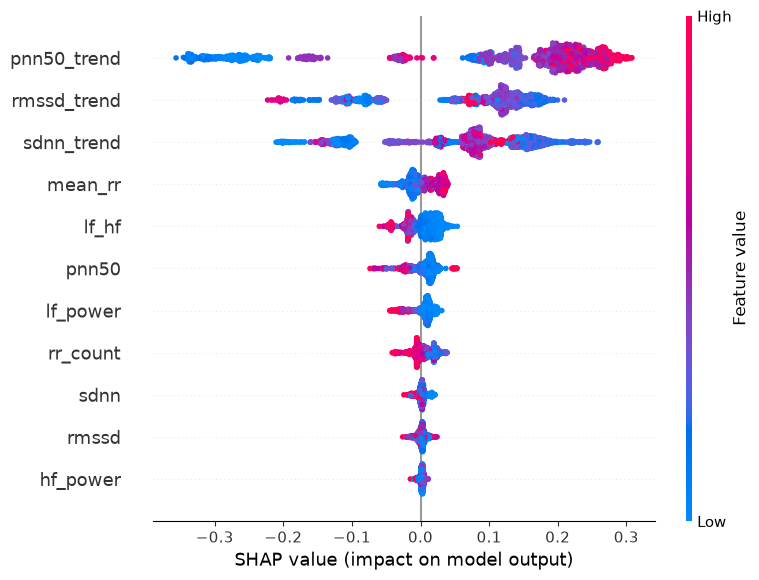

In [76]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values_class1,
    X_shap,
    show=True
)

In [77]:
# ============================================================
# CHECK X / DATASET ALIGNMENT
# ============================================================

print("X index matches ml_dataset index:",
      X.index.equals(ml_dataset.index))

print("X shape:", X.shape)
print("ml_dataset shape:", ml_dataset.shape)

print("\nml_dataset columns:")
print(list(ml_dataset.columns))

X index matches ml_dataset index: True
X shape: (11109, 11)
ml_dataset shape: (11109, 50)

ml_dataset columns:
['patient_id', 'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'window_id', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend', 'age', 'sex', 'nyha_class', 'risk_label', 'sdnn_baseline_mean', 'sdnn_baseline_std', 'rmssd_baseline_mean', 'rmssd_baseline_std', 'pnn50_baseline_mean', 'pnn50_baseline_std', 'lf_hf_baseline_mean', 'lf_hf_baseline_std', 'sdnn_z', 'rmssd_z', 'pnn50_z', 'lf_hf_z', 'personal_drift_score', 'history_count', 'baseline_confidence', 'drift_flag', 'sdnn_robust_baseline', 'sdnn_robust_mad', 'rmssd_robust_baseline', 'rmssd_robust_mad', 'pnn50_robust_baseline', 'pnn50_robust_mad', 'lf_hf_robust_baseline', 'lf_hf_robust_mad', 'sdnn_robust_z', 'rmssd_robust_z', 'pnn50_robust_z', 'lf_hf_robust_z', 'robust_drift_score', 'recent_drift_score', 'drift_acceleration', 'robust_drift_flag', 'drift_persistence']


In [78]:
# ============================================================
# FINAL RANDOM FOREST FOR SHAP EXPLANATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_shap.fit(X, y)

print("Final RF trained for SHAP.")
print("Trees:", rf_shap.n_estimators)
print("Features:", rf_shap.n_features_in_)

Final RF trained for SHAP.
Trees: 300
Features: 11


In [79]:
# ============================================================
# SHAP EXPLAINER FOR FINAL RF
# ============================================================

explainer_individual = shap.TreeExplainer(
    rf_shap
)

print("Individual SHAP explainer created.")

Individual SHAP explainer created.


In [80]:
# ============================================================
# SELECT PATIENT FOR INDIVIDUAL EXPLANATION
# ============================================================

PATIENT_ID = "chf04"

patient_rows = (
    ml_dataset[
        ml_dataset["patient_id"] == PATIENT_ID
    ]
    .sort_values("window_id")
)

latest_patient_row = patient_rows.tail(1)

print("Patient:", PATIENT_ID)
print("Number of windows:", len(patient_rows))
print("Latest window:", latest_patient_row["window_id"].iloc[0])

print("\nLatest patient data:")
print(
    latest_patient_row[
        [
            "patient_id",
            "window_id",
            "risk_label"
        ] + list(X.columns)
    ].to_string(index=False)
)

Patient: chf04
Number of windows: 240
Latest window: 239

Latest patient data:
patient_id  window_id  risk_label    mean_rr     sdnn     rmssd   pnn50  lf_power  hf_power    lf_hf  rr_count  sdnn_trend  rmssd_trend  pnn50_trend
     chf04        239           1 521.822695 9.852759 13.723481 0.71048  2.879512  7.120054 0.404423       564    0.001371     0.014499     0.017214


In [81]:
# ============================================================
# PATIENT RISK PREDICTION
# ============================================================

patient_index = latest_patient_row.index[0]

X_patient = X.loc[
    [patient_index]
]

patient_probability = rf_shap.predict_proba(
    X_patient
)[0, 1]

patient_prediction = int(
    patient_probability >= 0.5
)

print("Patient:", PATIENT_ID)
print(
    "Predicted risk probability:",
    round(patient_probability, 4)
)

print(
    "Predicted class:",
    patient_prediction
)

print(
    "Actual label:",
    int(latest_patient_row["risk_label"].iloc[0])
)

Patient: chf04
Predicted risk probability: 1.0
Predicted class: 1
Actual label: 1


In [82]:
# ============================================================
# INDIVIDUAL SHAP VALUES
# ============================================================

patient_shap_values = explainer_individual.shap_values(
    X_patient
)

patient_shap_class1 = (
    patient_shap_values[0, :, 1]
)

individual_shap = pd.DataFrame({
    "Feature": X.columns,
    "Feature_Value": X_patient.iloc[0].values,
    "SHAP_Value": patient_shap_class1
})

individual_shap["Absolute_SHAP"] = (
    individual_shap["SHAP_Value"]
    .abs()
)

individual_shap = (
    individual_shap
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    individual_shap.to_string(
        index=False
    )
)

    Feature  Feature_Value  SHAP_Value  Absolute_SHAP
 sdnn_trend       0.001371    0.194989       0.194989
pnn50_trend       0.017214    0.174119       0.174119
       sdnn       9.852759    0.037881       0.037881
   lf_power       2.879512    0.037072       0.037072
      lf_hf       0.404423    0.031174       0.031174
      pnn50       0.710480    0.008875       0.008875
    mean_rr     521.822695    0.007928       0.007928
   rr_count     564.000000    0.002733       0.002733
rmssd_trend       0.014499    0.002241       0.002241
   hf_power       7.120054    0.002019       0.002019
      rmssd      13.723481    0.000983       0.000983


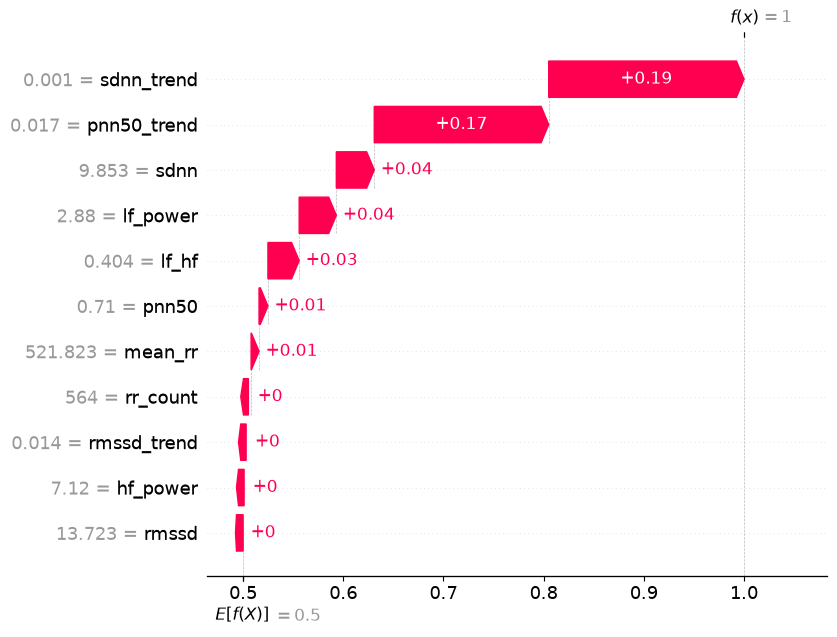

In [83]:
# ============================================================
# INDIVIDUAL PATIENT SHAP WATERFALL
# ============================================================

shap_explanation = shap.Explanation(
    values=patient_shap_class1,
    base_values=explainer_individual.expected_value[1],
    data=X_patient.iloc[0].values,
    feature_names=X.columns
)

shap.plots.waterfall(
    shap_explanation,
    max_display=11
)

In [84]:
# ============================================================
# MODEL UNCERTAINTY FROM RANDOM FOREST TREE DISAGREEMENT
# ============================================================

def rf_prediction_uncertainty(model, X_data):

    tree_probabilities = np.array([
        tree.predict_proba(X_data)[:, 1]
        for tree in model.estimators_
    ])

    mean_probability = (
        tree_probabilities.mean(axis=0)
    )

    probability_std = (
        tree_probabilities.std(axis=0)
    )

    return (
        mean_probability,
        probability_std
    )


rf_mean_probability, rf_probability_std = (
    rf_prediction_uncertainty(
        rf_shap,
        X
    )
)

print(
    "Mean RF probability:",
    round(
        rf_mean_probability.mean(),
        4
    )
)

print(
    "Mean tree disagreement:",
    round(
        rf_probability_std.mean(),
        4
    )
)

print(
    "\nMaximum tree disagreement:",
    round(
        rf_probability_std.max(),
        4
    )
)

C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but Dec

Mean RF probability: 0.715
Mean tree disagreement: 0.0239

Maximum tree disagreement: 0.325


C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\ddata\git program\chf-hrv-risk-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but Dec

In [85]:
# ============================================================
# PATIENT-LEVEL MODEL UNCERTAINTY
# ============================================================

uncertainty_df = ml_dataset[
    [
        "patient_id",
        "window_id"
    ]
].copy()

uncertainty_df[
    "rf_mean_probability"
] = rf_mean_probability

uncertainty_df[
    "rf_probability_std"
] = rf_probability_std

latest_uncertainty = (
    uncertainty_df
    .sort_values(
        ["patient_id", "window_id"]
    )
    .groupby("patient_id")
    .tail(1)
    .reset_index(drop=True)
)

print(
    latest_uncertainty.to_string(
        index=False
    )
)

patient_id  window_id  rf_mean_probability  rf_probability_std
     chf01        239             1.000000            0.000000
     chf02        229             0.993333            0.081377
     chf03        239             0.993333            0.081377
     chf04        239             1.000000            0.000000
     chf05        237             0.970000            0.170587
     chf06        236             0.990000            0.099499
     chf07        239             0.973333            0.161107
     chf08        239             0.980000            0.140000
     chf09        237             0.996667            0.057639
     chf10        238             0.953333            0.210924
     chf11        239             0.993333            0.081377
     chf12        237             0.993333            0.081377
     chf13        239             0.980000            0.140000
     chf14        239             1.000000            0.000000
     chf15        239             0.996667            0

In [86]:
# ============================================================
# PREDICTION CERTAINTY
# ============================================================

latest_uncertainty[
    "probability_certainty"
] = (
    2
    *
    (
        latest_uncertainty[
            "rf_mean_probability"
        ]
        - 0.5
    )
    .abs()
)

print(
    latest_uncertainty[
        [
            "patient_id",
            "rf_mean_probability",
            "rf_probability_std",
            "probability_certainty"
        ]
    ].head(20).to_string(index=False)
)

patient_id  rf_mean_probability  rf_probability_std  probability_certainty
     chf01             1.000000            0.000000               1.000000
     chf02             0.993333            0.081377               0.986667
     chf03             0.993333            0.081377               0.986667
     chf04             1.000000            0.000000               1.000000
     chf05             0.970000            0.170587               0.940000
     chf06             0.990000            0.099499               0.980000
     chf07             0.973333            0.161107               0.946667
     chf08             0.980000            0.140000               0.960000
     chf09             0.996667            0.057639               0.993333
     chf10             0.953333            0.210924               0.906667
     chf11             0.993333            0.081377               0.986667
     chf12             0.993333            0.081377               0.986667
     chf13             0.

In [87]:
# ============================================================
# FINAL PATIENT CONFIDENCE INFORMATION
# ============================================================

confidence_df = latest_uncertainty.merge(
    final_personalization[
        [
            "patient_id",
            "risk_label",
            "personalized_probability",
            "drift_signal",
            "history_count",
            "baseline_confidence"
        ]
    ],
    on="patient_id",
    how="inner"
)

print(
    confidence_df.shape
)

print(
    confidence_df.head().to_string(
        index=False
    )
)

(44, 10)
patient_id  window_id  rf_mean_probability  rf_probability_std  probability_certainty  risk_label  personalized_probability  drift_signal  history_count  baseline_confidence
     chf01        239             1.000000            0.000000               1.000000           1                  0.974237      0.204328            239                    1
     chf02        229             0.993333            0.081377               0.986667           1                  0.961599      0.374162            229                    1
     chf03        239             0.993333            0.081377               0.986667           1                  0.725041      0.287307            239                    1
     chf04        239             1.000000            0.000000               1.000000           1                  0.442385      0.465010            239                    1
     chf05        237             0.970000            0.170587               0.940000           1                  0.7594

In [88]:
# ============================================================
# CONFIDENCE FLAG
# ============================================================

def assign_confidence(row):

    if row["baseline_confidence"] == 0:
        return "Insufficient History"

    if row["rf_probability_std"] >= 0.15:
        return "Low Confidence"

    if row["probability_certainty"] < 0.20:
        return "Low Confidence"

    if row["rf_probability_std"] >= 0.10:
        return "Moderate Confidence"

    return "High Confidence"


confidence_df[
    "confidence_flag"
] = confidence_df.apply(
    assign_confidence,
    axis=1
)

print(
    confidence_df[
        [
            "patient_id",
            "personalized_probability",
            "rf_probability_std",
            "probability_certainty",
            "history_count",
            "confidence_flag"
        ]
    ].to_string(index=False)
)

patient_id  personalized_probability  rf_probability_std  probability_certainty  history_count     confidence_flag
     chf01                  0.974237            0.000000               1.000000            239     High Confidence
     chf02                  0.961599            0.081377               0.986667            229     High Confidence
     chf03                  0.725041            0.081377               0.986667            239     High Confidence
     chf04                  0.442385            0.000000               1.000000            239     High Confidence
     chf05                  0.759417            0.170587               0.940000            237      Low Confidence
     chf06                  0.261571            0.099499               0.980000            236     High Confidence
     chf07                  0.718034            0.161107               0.946667            239      Low Confidence
     chf08                  0.543171            0.140000               0.960000 

In [91]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

final_results = pd.DataFrame({
    "Model": [
        "RF Baseline",
        "Personalized RF",
        "GRU"
    ],
    "Accuracy": [
        0.709065,
        0.720947,
        0.613636
    ],
    "Precision": [
        0.767906,
        0.771145,
        0.894737
    ],
    "Recall": [
        0.851256,
        0.868216,
        0.531250
    ],
    "F1": [
        0.807436,
        0.816807,
        0.666667
    ],
    "AUROC": [
        0.567480,
        0.571633,
        0.747396
    ]
})

print(final_results.to_string(index=False))

          Model  Accuracy  Precision   Recall       F1    AUROC
    RF Baseline  0.709065   0.767906 0.851256 0.807436 0.567480
Personalized RF  0.720947   0.771145 0.868216 0.816807 0.571633
            GRU  0.613636   0.894737 0.531250 0.666667 0.747396


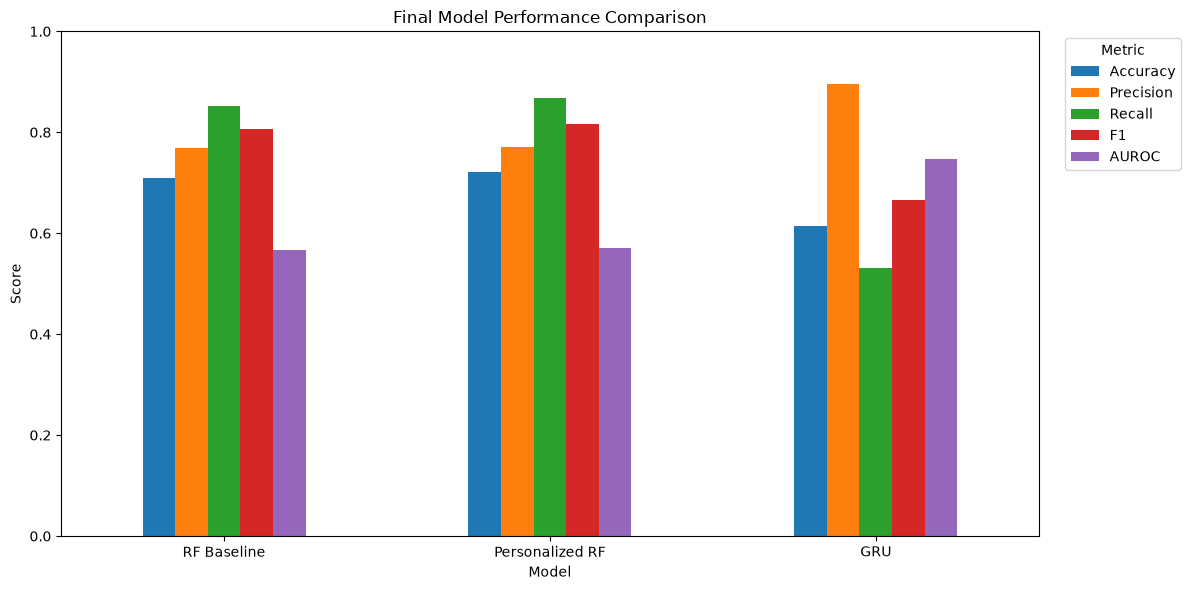

In [92]:
# ============================================================
# FINAL MODEL COMPARISON PLOT
# ============================================================

plot_data = final_results.set_index("Model")

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [93]:
# ============================================================
# FIND PATIENT-LEVEL DATAFRAMES
# ============================================================

import pandas as pd

print("DataFrames currently available:\n")

for name in sorted(list(globals().keys())):
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            cols = obj.columns.tolist()

            # Look for dataframes relevant to patient-level analysis
            relevant = [
                "patient_id",
                "risk_label",
                "personalized_probability",
                "rf_mean_probability",
                "rf_probability",
                "drift_signal",
                "history_count",
                "confidence_flag"
            ]

            matches = [c for c in relevant if c in cols]

            if matches:
                print("=" * 70)
                print("Variable:", name)
                print("Shape:", obj.shape)
                print("Matching columns:", matches)
                print("All columns:")
                print(cols)

    except Exception:
        pass

DataFrames currently available:

Variable: X_improved
Shape: (44, 9)
Matching columns: ['history_count']
All columns:
['current_rf_probability', 'recent_rf_probability', 'robust_drift_score', 'recent_drift_score', 'drift_acceleration', 'robust_drift_flag', 'drift_persistence', 'history_count', 'baseline_confidence_binary']
Variable: confidence_df
Shape: (44, 11)
Matching columns: ['patient_id', 'risk_label', 'personalized_probability', 'rf_mean_probability', 'drift_signal', 'history_count', 'confidence_flag']
All columns:
['patient_id', 'window_id', 'rf_mean_probability', 'rf_probability_std', 'probability_certainty', 'risk_label', 'personalized_probability', 'drift_signal', 'history_count', 'baseline_confidence', 'confidence_flag']
Variable: current_patient_state
Shape: (44, 8)
Matching columns: ['patient_id', 'risk_label', 'history_count']
All columns:
['patient_id', 'window_id', 'risk_label', 'nyha_class', 'personal_drift_score', 'history_count', 'baseline_confidence', 'drift_flag']

In [94]:
# ============================================================
# PATIENT-LEVEL ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# Start from the 44-patient RF OOF predictions
error_analysis = rf_oof.copy()

# Rename RF probability for clarity
error_analysis = error_analysis.rename(
    columns={
        "rf_probability": "rf_probability",
        "rf_prediction": "rf_prediction"
    }
)

# Add personalization information
personal_cols = [
    "patient_id",
    "personalized_probability",
    "drift_signal",
    "history_count",
    "baseline_confidence"
]

personal_info = confidence_df[personal_cols].copy()

error_analysis = error_analysis.merge(
    personal_info,
    on="patient_id",
    how="left"
)

# Personalized prediction using the same 0.5 threshold
error_analysis["personalized_prediction"] = (
    error_analysis["personalized_probability"] >= 0.5
).astype(int)

# Error flags
error_analysis["rf_correct"] = (
    error_analysis["rf_prediction"] == error_analysis["risk_label"]
)

error_analysis["personalized_correct"] = (
    error_analysis["personalized_prediction"] == error_analysis["risk_label"]
)

# Type of RF error
error_analysis["rf_error_type"] = np.where(
    error_analysis["rf_correct"],
    "Correct",
    np.where(
        error_analysis["rf_prediction"] == 1,
        "False Positive",
        "False Negative"
    )
)

# Type of Personalized RF error
error_analysis["personalized_error_type"] = np.where(
    error_analysis["personalized_correct"],
    "Correct",
    np.where(
        error_analysis["personalized_prediction"] == 1,
        "False Positive",
        "False Negative"
    )
)

# Whether personalization changed the prediction
error_analysis["prediction_changed"] = (
    error_analysis["rf_prediction"] !=
    error_analysis["personalized_prediction"]
)

# Change in probability caused by personalization
error_analysis["probability_change"] = (
    error_analysis["personalized_probability"] -
    error_analysis["rf_probability"]
)

# Sort by patient ID
error_analysis = error_analysis.sort_values(
    "patient_id"
).reset_index(drop=True)

print("Patient-level error analysis shape:")
print(error_analysis.shape)

print("\nColumns:")
print(error_analysis.columns.tolist())

print("\nComplete error-analysis table:")
print(error_analysis.to_string(index=False))

Patient-level error analysis shape:
(44, 15)

Columns:
['patient_id', 'risk_label', 'rf_probability', 'rf_prediction', 'personalized_probability', 'drift_signal', 'history_count', 'baseline_confidence', 'personalized_prediction', 'rf_correct', 'personalized_correct', 'rf_error_type', 'personalized_error_type', 'prediction_changed', 'probability_change']

Complete error-analysis table:
patient_id  risk_label  rf_probability  rf_prediction  personalized_probability  drift_signal  history_count  baseline_confidence  personalized_prediction  rf_correct  personalized_correct  rf_error_type personalized_error_type  prediction_changed  probability_change
     chf01           1        0.973139              1                  0.974237      0.204328            239                    1                        1        True                  True        Correct                 Correct               False            0.001098
     chf02           1        0.958493              1                  0.961

In [95]:
# ============================================================
# STEP 2: PATIENT-LEVEL ERROR SUMMARY
# ============================================================

print("=" * 70)
print("RF ERROR SUMMARY")
print("=" * 70)

print("\nRF prediction counts:")
print(error_analysis["rf_error_type"].value_counts())

print("\nRF errors:")
print(
    error_analysis[
        error_analysis["rf_correct"] == False
    ][[
        "patient_id",
        "risk_label",
        "rf_probability",
        "rf_prediction",
        "drift_signal",
        "history_count",
        "rf_error_type"
    ]].to_string(index=False)
)


print("\n" + "=" * 70)
print("PERSONALIZED RF ERROR SUMMARY")
print("=" * 70)

print("\nPersonalized RF prediction counts:")
print(error_analysis["personalized_error_type"].value_counts())

print("\nPersonalized RF errors:")
print(
    error_analysis[
        error_analysis["personalized_correct"] == False
    ][[
        "patient_id",
        "risk_label",
        "personalized_probability",
        "personalized_prediction",
        "drift_signal",
        "history_count",
        "personalized_error_type"
    ]].to_string(index=False)
)


print("\n" + "=" * 70)
print("PERSONALIZATION CHANGES")
print("=" * 70)

changed = error_analysis[
    error_analysis["prediction_changed"] == True
]

print("\nNumber of changed predictions:", len(changed))

if len(changed) > 0:
    print(
        changed[[
            "patient_id",
            "risk_label",
            "rf_probability",
            "personalized_probability",
            "probability_change",
            "drift_signal",
            "rf_prediction",
            "personalized_prediction"
        ]].to_string(index=False)
    )
else:
    print("No patient predictions changed at threshold 0.5.")


print("\n" + "=" * 70)
print("ERROR RATE")
print("=" * 70)

rf_error_rate = (~error_analysis["rf_correct"]).mean()
personalized_error_rate = (~error_analysis["personalized_correct"]).mean()

print(f"RF error rate: {rf_error_rate:.4f}")
print(f"Personalized RF error rate: {personalized_error_rate:.4f}")


print("\n" + "=" * 70)
print("AVERAGE DRIFT")
print("=" * 70)

print(
    "Correct RF predictions:",
    error_analysis.loc[
        error_analysis["rf_correct"], "drift_signal"
    ].mean()
)

print(
    "Incorrect RF predictions:",
    error_analysis.loc[
        ~error_analysis["rf_correct"], "drift_signal"
    ].mean()
)

print(
    "Correct Personalized RF predictions:",
    error_analysis.loc[
        error_analysis["personalized_correct"], "drift_signal"
    ].mean()
)

print(
    "Incorrect Personalized RF predictions:",
    error_analysis.loc[
        ~error_analysis["personalized_correct"], "drift_signal"
    ].mean()
)

RF ERROR SUMMARY

RF prediction counts:
rf_error_type
Correct           31
False Positive     8
False Negative     5
Name: count, dtype: int64

RF errors:
patient_id  risk_label  rf_probability  rf_prediction  drift_signal  history_count  rf_error_type
     chf04           1        0.385208              0      0.465010            239 False Negative
     chf06           1        0.240084              0      0.141377            236 False Negative
    chf210           1        0.125104              0      0.977786            272 False Negative
    chf211           0        0.773053              1      0.713194            284 False Positive
    chf212           0        0.949915              1      0.306398            195 False Positive
    chf214           0        0.990608              1      0.245726            202 False Positive
    chf216           0        0.961027              1      0.512227            262 False Positive
    chf217           0        0.886977              1      0.

In [96]:
# ============================================================
# STEP 3: PERSONALIZATION IMPACT ANALYSIS
# ============================================================

print("=" * 70)
print("LARGEST PERSONALIZATION PROBABILITY CHANGES")
print("=" * 70)

largest_changes = (
    error_analysis[
        [
            "patient_id",
            "risk_label",
            "rf_probability",
            "personalized_probability",
            "probability_change",
            "drift_signal",
            "rf_prediction",
            "personalized_prediction"
        ]
    ]
    .copy()
)

largest_changes["absolute_probability_change"] = (
    largest_changes["probability_change"].abs()
)

largest_changes = largest_changes.sort_values(
    "absolute_probability_change",
    ascending=False
)

print(
    largest_changes.head(15).to_string(index=False)
)


print("\n" + "=" * 70)
print("PERSONALIZATION IMPACT BY RISK GROUP")
print("=" * 70)

impact_summary = (
    error_analysis
    .groupby("risk_label")
    .agg(
        patients=("patient_id", "count"),
        mean_probability_change=("probability_change", "mean"),
        mean_absolute_change=("probability_change", lambda x: x.abs().mean()),
        mean_drift=("drift_signal", "mean")
    )
    .reset_index()
)

print(impact_summary.to_string(index=False))


print("\n" + "=" * 70)
print("PERSONALIZATION IMPACT BY PREDICTION CHANGE")
print("=" * 70)

print(
    error_analysis[
        error_analysis["prediction_changed"]
    ][[
        "patient_id",
        "risk_label",
        "rf_probability",
        "personalized_probability",
        "probability_change",
        "drift_signal"
    ]].to_string(index=False)
)

LARGEST PERSONALIZATION PROBABILITY CHANGES
patient_id  risk_label  rf_probability  personalized_probability  probability_change  drift_signal  rf_prediction  personalized_prediction  absolute_probability_change
    chf210           1        0.125104                  0.296196            0.171092      0.977786              0                        0                     0.171092
    chf223           1        0.100061                  0.209688            0.109626      0.609077              0                        0                     0.109626
    chf207           1        0.603950                  0.683160            0.079210      1.000000              1                        1                     0.079210
    chf218           0        0.245079                  0.313936            0.068857      0.456054              0                        0                     0.068857
     chf04           1        0.385208                  0.442385            0.057177      0.465010              0   

In [98]:
import pandas as pd

gru_analysis = pd.read_csv(
    "gru_patient_oof_for_analysis.csv"
)

print("GRU table loaded:")
print(gru_analysis.shape)
print(gru_analysis.head())

GRU table loaded:
(44, 4)
  patient_id  gru_actual  gru_probability  gru_prediction
0      chf01           1         0.756001               1
1      chf06           1         0.140538               0
2      chf11           1         0.562511               1
3     chf202           1         0.630838               1
4     chf208           1         0.689389               1


In [99]:
# ============================================================
# STEP 4C: COMBINE RF + PERSONALIZED RF + GRU
# ============================================================

combined_analysis = error_analysis.merge(
    gru_analysis,
    on="patient_id",
    how="inner"
)

# Check that the actual labels agree
combined_analysis["labels_agree"] = (
    combined_analysis["risk_label"] ==
    combined_analysis["gru_actual"]
)

# GRU correctness
combined_analysis["gru_correct"] = (
    combined_analysis["gru_prediction"] ==
    combined_analysis["risk_label"]
)

# RF vs GRU agreement
combined_analysis["rf_gru_agree"] = (
    combined_analysis["rf_prediction"] ==
    combined_analysis["gru_prediction"]
)

# Personalized RF vs GRU agreement
combined_analysis["personalized_gru_agree"] = (
    combined_analysis["personalized_prediction"] ==
    combined_analysis["gru_prediction"]
)

# All three models agree
combined_analysis["all_models_agree"] = (
    (combined_analysis["rf_prediction"] ==
     combined_analysis["personalized_prediction"]) &
    (combined_analysis["personalized_prediction"] ==
     combined_analysis["gru_prediction"])
)

# All three models correct
combined_analysis["all_models_correct"] = (
    combined_analysis["rf_correct"] &
    combined_analysis["personalized_correct"] &
    combined_analysis["gru_correct"]
)

# Number of models predicting risk
combined_analysis["models_predicting_risk"] = (
    combined_analysis["rf_prediction"] +
    combined_analysis["personalized_prediction"] +
    combined_analysis["gru_prediction"]
)

print("Combined analysis shape:")
print(combined_analysis.shape)

print("\nLabel agreement:")
print(combined_analysis["labels_agree"].value_counts())

print("\nFirst 10 rows:")
print(
    combined_analysis[
        [
            "patient_id",
            "risk_label",
            "rf_probability",
            "rf_prediction",
            "personalized_probability",
            "personalized_prediction",
            "gru_probability",
            "gru_prediction",
            "drift_signal"
        ]
    ].head(10).to_string(index=False)
)

Combined analysis shape:
(44, 25)

Label agreement:
labels_agree
True    44
Name: count, dtype: int64

First 10 rows:
patient_id  risk_label  rf_probability  rf_prediction  personalized_probability  personalized_prediction  gru_probability  gru_prediction  drift_signal
     chf01           1        0.973139              1                  0.974237                        1         0.756001               1      0.204328
     chf02           1        0.958493              1                  0.961599                        1         0.713678               1      0.374162
     chf03           1        0.708278              1                  0.725041                        1         0.532810               1      0.287307
     chf04           1        0.385208              0                  0.442385                        0         0.461869               0      0.465010
     chf05           1        0.719146              1                  0.759417                        1         0.624520 

In [100]:
# ============================================================
# STEP 5: FINAL MODEL AGREEMENT ANALYSIS
# ============================================================

print("=" * 70)
print("MODEL AGREEMENT")
print("=" * 70)

print("\nRF vs GRU agreement:")
print(
    combined_analysis["rf_gru_agree"].value_counts()
)

print(
    f"Agreement rate: "
    f"{combined_analysis['rf_gru_agree'].mean():.4f}"
)

print("\nPersonalized RF vs GRU agreement:")
print(
    combined_analysis["personalized_gru_agree"].value_counts()
)

print(
    f"Agreement rate: "
    f"{combined_analysis['personalized_gru_agree'].mean():.4f}"
)

print("\nAll three models agreement:")
print(
    combined_analysis["all_models_agree"].value_counts()
)

print(
    f"Agreement rate: "
    f"{combined_analysis['all_models_agree'].mean():.4f}"
)


# ============================================================
# CORRECTNESS BY MODEL
# ============================================================

print("\n" + "=" * 70)
print("CORRECTNESS BY MODEL")
print("=" * 70)

print(
    f"RF correct: "
    f"{combined_analysis['rf_correct'].sum()}/44"
)

print(
    f"Personalized RF correct: "
    f"{combined_analysis['personalized_correct'].sum()}/44"
)

print(
    f"GRU correct: "
    f"{combined_analysis['gru_correct'].sum()}/44"
)


# ============================================================
# ALL MODELS CORRECT
# ============================================================

all_correct = combined_analysis[
    combined_analysis["all_models_correct"]
]

print("\n" + "=" * 70)
print("PATIENTS CORRECTLY CLASSIFIED BY ALL THREE MODELS")
print("=" * 70)

print(
    f"Count: {len(all_correct)}"
)

print(
    all_correct[
        [
            "patient_id",
            "risk_label",
            "rf_probability",
            "personalized_probability",
            "gru_probability",
            "drift_signal"
        ]
    ].to_string(index=False)
)


# ============================================================
# ALL MODELS WRONG
# ============================================================

all_wrong = combined_analysis[
    (~combined_analysis["rf_correct"]) &
    (~combined_analysis["personalized_correct"]) &
    (~combined_analysis["gru_correct"])
]

print("\n" + "=" * 70)
print("PATIENTS MISCLASSIFIED BY ALL THREE MODELS")
print("=" * 70)

print(
    f"Count: {len(all_wrong)}"
)

if len(all_wrong) > 0:
    print(
        all_wrong[
            [
                "patient_id",
                "risk_label",
                "rf_probability",
                "personalized_probability",
                "gru_probability",
                "drift_signal"
            ]
        ].to_string(index=False)
    )
else:
    print("No patient was misclassified by all three models.")


# ============================================================
# MODEL DISAGREEMENT
# ============================================================

disagreement = combined_analysis[
    ~combined_analysis["all_models_agree"]
]

print("\n" + "=" * 70)
print("MODEL DISAGREEMENT")
print("=" * 70)

print(
    f"Number of disagreement cases: {len(disagreement)}"
)

print(
    disagreement[
        [
            "patient_id",
            "risk_label",
            "rf_prediction",
            "personalized_prediction",
            "gru_prediction",
            "rf_probability",
            "personalized_probability",
            "gru_probability",
            "drift_signal"
        ]
    ].to_string(index=False)
)


# ============================================================
# THREE-MODEL VOTE
# ============================================================

print("\n" + "=" * 70)
print("NUMBER OF MODELS PREDICTING HIGH RISK")
print("=" * 70)

print(
    combined_analysis[
        "models_predicting_risk"
    ].value_counts().sort_index()
)

MODEL AGREEMENT

RF vs GRU agreement:
rf_gru_agree
True     28
False    16
Name: count, dtype: int64
Agreement rate: 0.6364

Personalized RF vs GRU agreement:
personalized_gru_agree
True     27
False    17
Name: count, dtype: int64
Agreement rate: 0.6136

All three models agreement:
all_models_agree
True     27
False    17
Name: count, dtype: int64
Agreement rate: 0.6136

CORRECTNESS BY MODEL
RF correct: 31/44
Personalized RF correct: 32/44
GRU correct: 27/44

PATIENTS CORRECTLY CLASSIFIED BY ALL THREE MODELS
Count: 21
patient_id  risk_label  rf_probability  personalized_probability  gru_probability  drift_signal
     chf01           1        0.973139                  0.974237         0.756001      0.204328
     chf02           1        0.958493                  0.961599         0.713678      0.374162
     chf03           1        0.708278                  0.725041         0.532810      0.287307
     chf05           1        0.719146                  0.759417         0.624520      0.71

In [101]:
# ============================================================
# STEP 6: THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

y_true = combined_analysis["risk_label"].values

for threshold in thresholds:

    # Personalized RF
    personalized_pred = (
        combined_analysis["personalized_probability"].values >= threshold
    ).astype(int)

    # GRU
    gru_pred = (
        combined_analysis["gru_probability"].values >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),

        "personalized_accuracy":
            accuracy_score(y_true, personalized_pred),

        "personalized_precision":
            precision_score(
                y_true,
                personalized_pred,
                zero_division=0
            ),

        "personalized_recall":
            recall_score(
                y_true,
                personalized_pred,
                zero_division=0
            ),

        "personalized_f1":
            f1_score(
                y_true,
                personalized_pred,
                zero_division=0
            ),

        "gru_accuracy":
            accuracy_score(y_true, gru_pred),

        "gru_precision":
            precision_score(
                y_true,
                gru_pred,
                zero_division=0
            ),

        "gru_recall":
            recall_score(
                y_true,
                gru_pred,
                zero_division=0
            ),

        "gru_f1":
            f1_score(
                y_true,
                gru_pred,
                zero_division=0
            )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("=" * 80)
print("THRESHOLD ANALYSIS")
print("=" * 80)

print(
    threshold_results_df.to_string(index=False)
)

THRESHOLD ANALYSIS
 threshold  personalized_accuracy  personalized_precision  personalized_recall  personalized_f1  gru_accuracy  gru_precision  gru_recall   gru_f1
      0.20               0.750000                0.744186              1.00000         0.853333      0.704545       0.720930     0.96875 0.826667
      0.25               0.727273                0.738095              0.96875         0.837838      0.681818       0.725000     0.90625 0.805556
      0.30               0.727273                0.763158              0.90625         0.828571      0.681818       0.725000     0.90625 0.805556
      0.35               0.750000                0.783784              0.90625         0.840580      0.704545       0.743590     0.90625 0.816901
      0.40               0.750000                0.783784              0.90625         0.840580      0.727273       0.794118     0.84375 0.818182
      0.45               0.727273                0.777778              0.87500         0.823529      0.75

In [102]:
# ============================================================
# FIND BEST F1 THRESHOLDS
# ============================================================

best_personalized = threshold_results_df.loc[
    threshold_results_df["personalized_f1"].idxmax()
]

best_gru = threshold_results_df.loc[
    threshold_results_df["gru_f1"].idxmax()
]

print("\n" + "=" * 80)
print("BEST PERSONALIZED RF F1 THRESHOLD")
print("=" * 80)

print(best_personalized.to_string())

print("\n" + "=" * 80)
print("BEST GRU F1 THRESHOLD")
print("=" * 80)

print(best_gru.to_string())


BEST PERSONALIZED RF F1 THRESHOLD
threshold                 0.200000
personalized_accuracy     0.750000
personalized_precision    0.744186
personalized_recall       1.000000
personalized_f1           0.853333
gru_accuracy              0.704545
gru_precision             0.720930
gru_recall                0.968750
gru_f1                    0.826667

BEST GRU F1 THRESHOLD
threshold                 0.200000
personalized_accuracy     0.750000
personalized_precision    0.744186
personalized_recall       1.000000
personalized_f1           0.853333
gru_accuracy              0.704545
gru_precision             0.720930
gru_recall                0.968750
gru_f1                    0.826667


In [103]:
# ============================================================
# RECALL-ORIENTED THRESHOLD ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("THRESHOLDS WITH RECALL >= 0.80")
print("=" * 80)

high_recall = threshold_results_df[
    (threshold_results_df["personalized_recall"] >= 0.80) |
    (threshold_results_df["gru_recall"] >= 0.80)
]

print(
    high_recall.to_string(index=False)
)


THRESHOLDS WITH RECALL >= 0.80
 threshold  personalized_accuracy  personalized_precision  personalized_recall  personalized_f1  gru_accuracy  gru_precision  gru_recall   gru_f1
      0.20               0.750000                0.744186              1.00000         0.853333      0.704545       0.720930     0.96875 0.826667
      0.25               0.727273                0.738095              0.96875         0.837838      0.681818       0.725000     0.90625 0.805556
      0.30               0.727273                0.763158              0.90625         0.828571      0.681818       0.725000     0.90625 0.805556
      0.35               0.750000                0.783784              0.90625         0.840580      0.704545       0.743590     0.90625 0.816901
      0.40               0.750000                0.783784              0.90625         0.840580      0.727273       0.794118     0.84375 0.818182
      0.45               0.727273                0.777778              0.87500         0.823

In [106]:
import pandas as pd
import numpy as np

# ============================================================
# PATIENT RISK STRATIFICATION
# ============================================================

# Start from the combined patient-level results
risk_data = combined_analysis.copy()

print("Available columns:")
print(risk_data.columns.tolist())

# ------------------------------------------------------------
# Add probability certainty if RF std is available
# ------------------------------------------------------------

if "rf_probability_std" in risk_data.columns:
    risk_data["probability_certainty"] = (
        1 - risk_data["rf_probability_std"]
    ).clip(0, 1)

elif "probability_certainty" not in risk_data.columns:
    # Try to recover it from an existing patient-level RF table
    source_df = None

    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            if {
                "patient_id",
                "rf_probability_std"
            }.issubset(cols):

                source_df = obj[
                    [
                        "patient_id",
                        "rf_probability_std"
                    ]
                ].drop_duplicates("patient_id")

                print(
                    "Recovered rf_probability_std from:",
                    name
                )
                break

    if source_df is not None:

        risk_data = risk_data.merge(
            source_df,
            on="patient_id",
            how="left"
        )

        risk_data["probability_certainty"] = (
            1 - risk_data["rf_probability_std"]
        ).clip(0, 1)

    else:
        print(
            "rf_probability_std not found. "
            "Setting probability_certainty to NaN."
        )

        risk_data["probability_certainty"] = np.nan


# ------------------------------------------------------------
# Determine personalized prediction
# ------------------------------------------------------------

if "personalized_prediction" not in risk_data.columns:

    risk_data["personalized_prediction"] = (
        risk_data["personalized_probability"] >= 0.5
    ).astype(int)


# ------------------------------------------------------------
# Confidence flag
# ------------------------------------------------------------

def confidence_level(row):

    p = row["personalized_probability"]

    if p >= 0.8 or p <= 0.2:
        return "High Confidence"

    elif p >= 0.6 or p <= 0.4:
        return "Moderate Confidence"

    else:
        return "Low Confidence"


risk_data["confidence_flag"] = risk_data.apply(
    confidence_level,
    axis=1
)


# ------------------------------------------------------------
# Risk category
# ------------------------------------------------------------

def risk_category(p):

    if p >= 0.8:
        return "High Risk"

    elif p >= 0.5:
        return "Moderate Risk"

    else:
        return "Low Risk"


risk_data["risk_category"] = (
    risk_data["personalized_probability"]
    .apply(risk_category)
)


# ------------------------------------------------------------
# Prediction correctness
# ------------------------------------------------------------

risk_data["prediction_correct"] = (
    risk_data["personalized_prediction"]
    == risk_data["risk_label"]
)


# ------------------------------------------------------------
# Display final patient risk table
# ------------------------------------------------------------

display_columns = [
    "patient_id",
    "risk_label",
    "personalized_probability",
    "personalized_prediction",
    "risk_category",
    "drift_signal",
    "history_count",
    "baseline_confidence",
    "probability_certainty",
    "confidence_flag",
    "prediction_correct"
]

# Keep only columns that actually exist
display_columns = [
    c for c in display_columns
    if c in risk_data.columns
]

print()
print("=" * 80)
print("PATIENT RISK STRATIFICATION")
print("=" * 80)

print(
    risk_data[display_columns]
    .sort_values(
        "personalized_probability",
        ascending=False
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# Risk-group summary
# ------------------------------------------------------------

print()
print("=" * 80)
print("RISK GROUP SUMMARY")
print("=" * 80)

risk_summary = (
    risk_data
    .groupby("risk_category")
    .agg(
        patients=("patient_id", "count"),
        mean_probability=(
            "personalized_probability",
            "mean"
        ),
        mean_drift=(
            "drift_signal",
            "mean"
        ),
        correct_predictions=(
            "prediction_correct",
            "sum"
        )
    )
    .reset_index()
)

risk_summary["accuracy"] = (
    risk_summary["correct_predictions"]
    / risk_summary["patients"]
)

print(risk_summary.to_string(index=False))

Available columns:
['patient_id', 'risk_label', 'rf_probability', 'rf_prediction', 'personalized_probability', 'drift_signal', 'history_count', 'baseline_confidence', 'personalized_prediction', 'rf_correct', 'personalized_correct', 'rf_error_type', 'personalized_error_type', 'prediction_changed', 'probability_change', 'gru_actual', 'gru_probability', 'gru_prediction', 'labels_agree', 'gru_correct', 'rf_gru_agree', 'personalized_gru_agree', 'all_models_agree', 'all_models_correct', 'models_predicting_risk']
Recovered rf_probability_std from: uncertainty_df

PATIENT RISK STRATIFICATION
patient_id  risk_label  personalized_probability  personalized_prediction risk_category  drift_signal  history_count  baseline_confidence  probability_certainty     confidence_flag  prediction_correct
     chf15           1                  0.999159                        1     High Risk      0.964558            239                    1               0.860000     High Confidence                True
    chf

In [107]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# ------------------------------------------------------------
# 1. Prepare predictions
# ------------------------------------------------------------

y_true = combined_analysis["risk_label"]

y_rf = combined_analysis["rf_prediction"]
p_rf = combined_analysis["rf_probability"]

y_personalized = combined_analysis["personalized_prediction"]
p_personalized = combined_analysis["personalized_probability"]

y_gru = combined_analysis["gru_prediction"]
p_gru = combined_analysis["gru_probability"]

# ------------------------------------------------------------
# 2. Calculate metrics
# ------------------------------------------------------------

final_results = pd.DataFrame({
    "Model": [
        "RF Baseline",
        "Personalized RF",
        "GRU"
    ],
    "Accuracy": [
        accuracy_score(y_true, y_rf),
        accuracy_score(y_true, y_personalized),
        accuracy_score(y_true, y_gru)
    ],
    "Precision": [
        precision_score(y_true, y_rf),
        precision_score(y_true, y_personalized),
        precision_score(y_true, y_gru)
    ],
    "Recall": [
        recall_score(y_true, y_rf),
        recall_score(y_true, y_personalized),
        recall_score(y_true, y_gru)
    ],
    "F1": [
        f1_score(y_true, y_rf),
        f1_score(y_true, y_personalized),
        f1_score(y_true, y_gru)
    ],
    "AUROC": [
        roc_auc_score(y_true, p_rf),
        roc_auc_score(y_true, p_personalized),
        roc_auc_score(y_true, p_gru)
    ]
})

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(final_results.to_string(index=False))

# ------------------------------------------------------------
# 3. Improvements of Personalized RF over Baseline RF
# ------------------------------------------------------------

rf_row = final_results.iloc[0]
personalized_row = final_results.iloc[1]

improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ],
    "RF Baseline": [
        rf_row["Accuracy"],
        rf_row["Precision"],
        rf_row["Recall"],
        rf_row["F1"],
        rf_row["AUROC"]
    ],
    "Personalized RF": [
        personalized_row["Accuracy"],
        personalized_row["Precision"],
        personalized_row["Recall"],
        personalized_row["F1"],
        personalized_row["AUROC"]
    ]
})

improvement["Change"] = (
    improvement["Personalized RF"] -
    improvement["RF Baseline"]
)

print()
print("=" * 80)
print("PERSONALIZATION IMPROVEMENT")
print("=" * 80)

print(improvement.to_string(index=False))

# ------------------------------------------------------------
# 4. Error counts
# ------------------------------------------------------------

print()
print("=" * 80)
print("ERROR COMPARISON")
print("=" * 80)

rf_errors = (y_rf != y_true).sum()
personalized_errors = (y_personalized != y_true).sum()
gru_errors = (y_gru != y_true).sum()

print("RF Baseline errors     :", rf_errors)
print("Personalized RF errors :", personalized_errors)
print("GRU errors             :", gru_errors)

print()
print("RF -> Personalized RF error reduction:",
      rf_errors - personalized_errors)

FINAL MODEL COMPARISON
          Model  Accuracy  Precision  Recall       F1    AUROC
    RF Baseline  0.704545   0.771429 0.84375 0.805970 0.554688
Personalized RF  0.727273   0.777778 0.87500 0.823529 0.557292
            GRU  0.613636   0.894737 0.53125 0.666667 0.747396

PERSONALIZATION IMPROVEMENT
   Metric  RF Baseline  Personalized RF   Change
 Accuracy     0.704545         0.727273 0.022727
Precision     0.771429         0.777778 0.006349
   Recall     0.843750         0.875000 0.031250
       F1     0.805970         0.823529 0.017559
    AUROC     0.554688         0.557292 0.002604

ERROR COMPARISON
RF Baseline errors     : 13
Personalized RF errors : 12
GRU errors             : 17

RF -> Personalized RF error reduction: 1


In [108]:
# ============================================================
# PERSONALIZATION vs PATIENT DRIFT ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

analysis = combined_analysis.copy()

# Absolute magnitude of personalization adjustment
analysis["absolute_probability_change"] = (
    analysis["personalized_probability"] -
    analysis["rf_probability"]
).abs()

print("=" * 80)
print("PERSONALIZATION vs PATIENT DRIFT")
print("=" * 80)

print("\nNumber of patients:", len(analysis))

# ------------------------------------------------------------
# 1. Correlation between drift and personalization change
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    analysis["drift_signal"],
    analysis["absolute_probability_change"]
)

spearman_r, spearman_p = spearmanr(
    analysis["drift_signal"],
    analysis["absolute_probability_change"]
)

print("\nPearson correlation:")
print("r =", round(pearson_r, 4))
print("p-value =", round(pearson_p, 6))

print("\nSpearman correlation:")
print("rho =", round(spearman_r, 4))
print("p-value =", round(spearman_p, 6))

# ------------------------------------------------------------
# 2. Compare low-drift and high-drift patients
# ------------------------------------------------------------

drift_median = analysis["drift_signal"].median()

analysis["drift_group"] = np.where(
    analysis["drift_signal"] >= drift_median,
    "High Drift",
    "Low Drift"
)

drift_summary = (
    analysis
    .groupby("drift_group")
    .agg(
        patients=("patient_id", "count"),
        mean_drift=("drift_signal", "mean"),
        mean_probability_change=(
            "absolute_probability_change",
            "mean"
        ),
        median_probability_change=(
            "absolute_probability_change",
            "median"
        )
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("LOW vs HIGH DRIFT")
print("=" * 80)

print(drift_summary.to_string(index=False))

# ------------------------------------------------------------
# 3. Show patients with largest personalization changes
# ------------------------------------------------------------

largest_changes = (
    analysis[
        [
            "patient_id",
            "risk_label",
            "rf_probability",
            "personalized_probability",
            "absolute_probability_change",
            "drift_signal"
        ]
    ]
    .sort_values(
        "absolute_probability_change",
        ascending=False
    )
    .head(15)
)

print("\n" + "=" * 80)
print("LARGEST PERSONALIZATION CHANGES")
print("=" * 80)

print(largest_changes.to_string(index=False))

# ------------------------------------------------------------
# 4. Drift and personalization by risk group
# ------------------------------------------------------------

risk_summary = (
    analysis
    .groupby("risk_label")
    .agg(
        patients=("patient_id", "count"),
        mean_drift=("drift_signal", "mean"),
        mean_probability_change=(
            "absolute_probability_change",
            "mean"
        ),
        median_probability_change=(
            "absolute_probability_change",
            "median"
        )
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("PERSONALIZATION BY RISK LABEL")
print("=" * 80)

print(risk_summary.to_string(index=False))

PERSONALIZATION vs PATIENT DRIFT

Number of patients: 44

Pearson correlation:
r = 0.5264
p-value = 0.000242

Spearman correlation:
rho = 0.421
p-value = 0.00443

LOW vs HIGH DRIFT
drift_group  patients  mean_drift  mean_probability_change  median_probability_change
 High Drift        22    0.606096                 0.037231                   0.020296
  Low Drift        22    0.256831                 0.013794                   0.004298

LARGEST PERSONALIZATION CHANGES
patient_id  risk_label  rf_probability  personalized_probability  absolute_probability_change  drift_signal
    chf210           1        0.125104                  0.296196                     0.171092      0.977786
    chf223           1        0.100061                  0.209688                     0.109626      0.609077
    chf207           1        0.603950                  0.683160                     0.079210      1.000000
    chf218           0        0.245079                  0.313936                     0.068857   

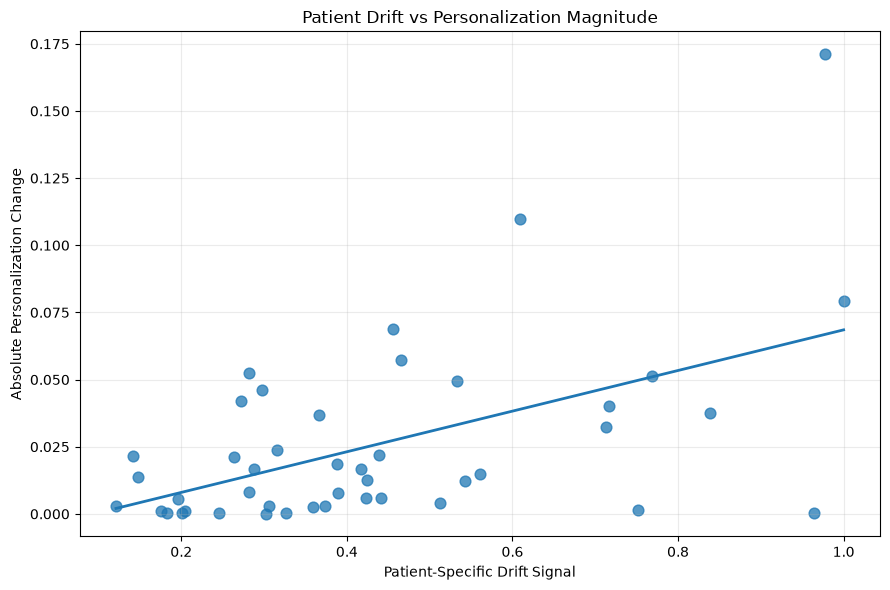

Pearson correlation: 0.5264
Spearman correlation: 0.4210


In [109]:
# ============================================================
# FIGURE: PATIENT DRIFT vs PERSONALIZATION MAGNITUDE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_data = combined_analysis.copy()

plot_data["absolute_probability_change"] = (
    plot_data["personalized_probability"]
    - plot_data["rf_probability"]
).abs()

x = plot_data["drift_signal"].values
y = plot_data["absolute_probability_change"].values

# Linear trend
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(9, 6))

plt.scatter(
    x,
    y,
    s=60,
    alpha=0.75
)

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("Patient-Specific Drift Signal")
plt.ylabel("Absolute Personalization Change")
plt.title("Patient Drift vs Personalization Magnitude")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

print("Pearson correlation: 0.5264")
print("Spearman correlation: 0.4210")

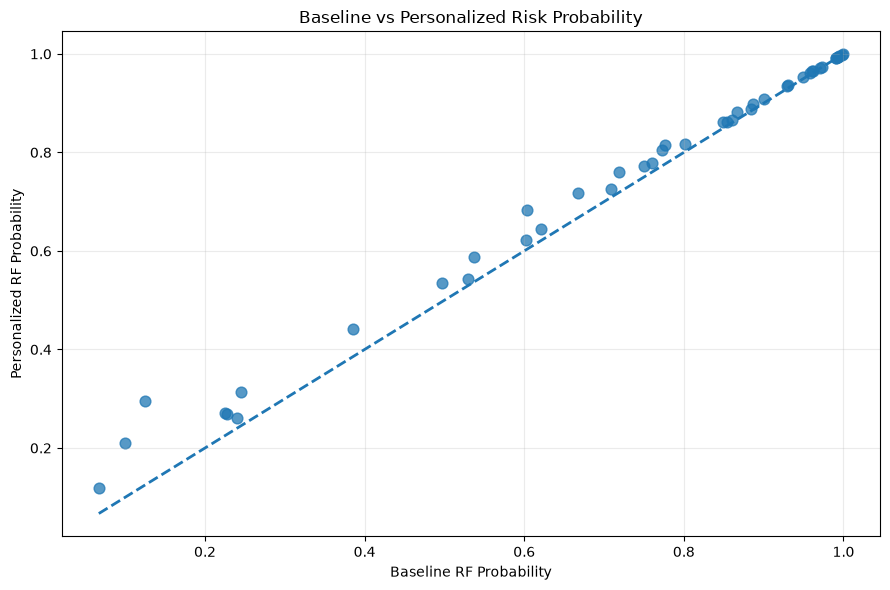

In [110]:
# ============================================================
# FIGURE: BASELINE RF vs PERSONALIZED RF
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_data["rf_probability"],
    plot_data["personalized_probability"],
    s=60,
    alpha=0.75
)

# Reference line: no personalization change
minimum = min(
    plot_data["rf_probability"].min(),
    plot_data["personalized_probability"].min()
)

maximum = max(
    plot_data["rf_probability"].max(),
    plot_data["personalized_probability"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Baseline RF Probability")
plt.ylabel("Personalized RF Probability")
plt.title("Baseline vs Personalized Risk Probability")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()